## Projet 7 : Implementez un modèle de scoring 

In [17]:
'application_train.csv'

'application_train.csv'

In [1]:
import numpy as np
import pandas as pd
import gc
import time
from contextlib import contextmanager
from lightgbm import LGBMClassifier
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.model_selection import KFold, StratifiedKFold
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [2]:
pd.set_option('display.max_row', 20)
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 500)

In [20]:
pip install scikit-learn

In [21]:
pip install seaborn

ERROR: Operation cancelled by user


In [3]:
@contextmanager
def timer(title):
    t0 = time.time()
    yield
    print("{} - done in {:.0f}s".format(title, time.time() - t0))

# 1) Import des bases de données

In [3]:
train_df = pd.read_csv('application_train.csv', nrows=None)
test_df = pd.read_csv('application_test.csv', nrows=None)
print(f"Train samples: {len(train_df):,}, test samples: {len(test_df):,}")

Train samples: 307,511, test samples: 48,744


In [ ]:
def contenu_df(dataframe,numberhead=3):
    print(dataframe.shape)
    display(dataframe.isnull().sum())
    Doublons= dataframe.duplicated().sum()
    print(f'cette dataframe contient :{Doublons} doublons')
    display(dataframe.head(numberhead))

In [ ]:
contenu_df(train_df)

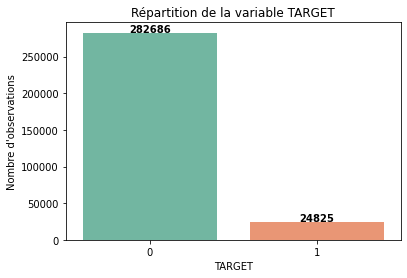

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Comptage brut
counts = train_df['TARGET'].value_counts()

# Barplot avec seaborn
plt.figure(figsize=(6,4))
sns.barplot(x=counts.index, y=counts.values, palette="Set2")

plt.title("Répartition de la variable TARGET")
plt.xlabel("TARGET")
plt.ylabel("Nombre d'observations")

# Afficher les valeurs au-dessus des barres
for i, v in enumerate(counts.values):
    plt.text(i, v + 500, str(v), ha='center', fontweight='bold')

plt.show()


In [6]:
def valeur_manquantes_variables (df):
    print("Nombre et pourcentage de valeurs manquantes par variable")
    values = df.isnull().sum()
    percentage = 100 * values / len(df)
    table = pd.concat([values, percentage.round(2)], axis=1)
    table.columns = ['Nb de valeurs manquantes'
                         ,'% de valeurs manquantes']
    display(table[table['Nb de valeurs manquantes'] > 60]
                .sort_values('% de valeurs manquantes', ascending = False)
                .style.background_gradient('Reds'))

In [ ]:
contenu_df(test_df)

On vérifie que les df_train et test ont bien les mêmes colonnes et que la colonne de différenc est bien la TARGET

In [4]:
# Colonnes de chaque df
cols_train = set(train_df.columns)
cols_test  = set(test_df.columns)

# Différences
print("Colonnes dans train mais pas dans test :", cols_train - cols_test)
print("Colonnes dans test mais pas dans train :", cols_test - cols_train)

# Colonnes communes
print("Nombre de colonnes communes :", len(cols_train & cols_test))


Colonnes dans train mais pas dans test : {'TARGET'}
Colonnes dans test mais pas dans train : set()
Nombre de colonnes communes : 121


Nous allons fusionner les deux df. En prenant soint de creer une colonne TARGET dans la test

In [5]:
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

# Ajouter une colonne TARGET vide dans le test
test_df["TARGET"] = np.nan

# Concat train + test
df_all = pd.concat([train_df, test_df], axis=0).reset_index(drop=True)

print("Combined shape:", df_all.shape)


Train shape: (307511, 122)
Test shape: (48744, 121)
Combined shape: (356255, 122)


In [6]:
df_all.shape

(356255, 122)

In [7]:
df=df_all.copy()

df.shape

(356255, 122)

In [8]:
counts = df_all['TARGET'].value_counts()
counts

0.0    282686
1.0     24825
Name: TARGET, dtype: int64

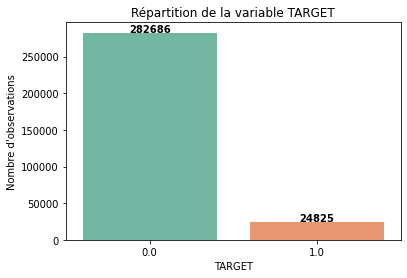

In [13]:


# Comptage brut
counts = df['TARGET'].value_counts()

# Barplot avec seaborn
plt.figure(figsize=(6,4))
sns.barplot(x=counts.index, y=counts.values, palette="Set2")

plt.title("Répartition de la variable TARGET")
plt.xlabel("TARGET")
plt.ylabel("Nombre d'observations")

# Afficher les valeurs au-dessus des barres
for i, v in enumerate(counts.values):
    plt.text(i, v + 500, str(v), ha='center', fontweight='bold')

plt.show()


In [ ]:
TARGET = 1 → le client a eu des difficultés de remboursement (il est en défaut, au moins 90 jours de retard sur son prêt).

TARGET = 0 → le client a remboursé correctement son crédit, sans retard majeur.

En résumé :

1 = mauvais payeur (défaut de crédit)

0 = bon payeur

# 2) Descriptions des variables & nettoyage de données

In [14]:
df.dtypes

SK_ID_CURR                      int64
TARGET                        float64
NAME_CONTRACT_TYPE             object
CODE_GENDER                    object
FLAG_OWN_CAR                   object
                               ...   
AMT_REQ_CREDIT_BUREAU_DAY     float64
AMT_REQ_CREDIT_BUREAU_WEEK    float64
AMT_REQ_CREDIT_BUREAU_MON     float64
AMT_REQ_CREDIT_BUREAU_QRT     float64
AMT_REQ_CREDIT_BUREAU_YEAR    float64
Length: 122, dtype: object

In [9]:
# 1. Variables object (catégorielles textuelles)
df_object = df_all.select_dtypes(include=['object'])

# 2. Variables numériques (int, float)
df_numeric = df.select_dtypes(include=[np.number])

# 3. Variables binaires (parmi les numériques : seulement 0/1 ou True/False)
binary_cols = [col for col in df_numeric.columns
               if set(df_numeric[col].dropna().unique()).issubset({0,1})]

df_binary = df[binary_cols]

print("Nombre de colonnes object :", df_object.shape[1])
print("Nombre de colonnes numériques :", df_numeric.shape[1])
print("Nombre de colonnes binaires :", df_binary.shape[1])


Nombre de colonnes object : 16
Nombre de colonnes numériques : 106
Nombre de colonnes binaires : 33


# df_object

In [10]:
df_object.head(4)

,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,OCCUPATION_TYPE,WEEKDAY_APPR_PROCESS_START,ORGANIZATION_TYPE,FONDKAPREMONT_MODE,HOUSETYPE_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE
0,Cash loans,M,N,Y,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,Laborers,WEDNESDAY,Business Entity Type 3,reg oper account,block of flats,"Stone, brick",No
1,Cash loans,F,N,N,Family,State servant,Higher education,Married,House / apartment,Core staff,MONDAY,School,reg oper account,block of flats,Block,No
2,Revolving loans,M,Y,Y,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,Laborers,MONDAY,Government,NaN,NaN,NaN,NaN
3,Cash loans,F,N,Y,Unaccompanied,Working,Secondary / secondary special,Civil marriage,House / apartment,Laborers,WEDNESDAY,Business Entity Type 3,NaN,NaN,NaN,NaN


In [17]:
df_object.isnull().sum().sort_values(ascending=False)

FONDKAPREMONT_MODE            243092
WALLSMATERIAL_MODE            180234
HOUSETYPE_MODE                177916
EMERGENCYSTATE_MODE           167964
OCCUPATION_TYPE               111996
NAME_TYPE_SUITE                 2203
NAME_CONTRACT_TYPE                 0
CODE_GENDER                        0
FLAG_OWN_CAR                       0
FLAG_OWN_REALTY                    0
NAME_INCOME_TYPE                   0
NAME_EDUCATION_TYPE                0
NAME_FAMILY_STATUS                 0
NAME_HOUSING_TYPE                  0
WEEKDAY_APPR_PROCESS_START         0
ORGANIZATION_TYPE                  0
dtype: int64

**WALLSMATERIAL_MODE**
Type de matériau principal des murs du logement (pierre, brique, panneau, bloc, etc.).
→ Beaucoup de NaN = info non collectée par la banque pour la majorité des clients : information peu discriminante : à supp

**HOUSETYPE_MODE**
Type de maison/appartement : maison individuelle, appartement dans un bloc, etc.
→ Là aussi énormément de manquants. information à suppr

**EMERGENCYSTATE_MODE**
Si la personne vit dans une zone d’état d’urgence (catastrophe, guerre locale…).
→ Presque toujours vide, car rare.

**OCCUPATION_TYPE ** Profession principale du client : important à conserver 

*variables à très forte cardinalité


In [11]:
for col in df.select_dtypes('object'):
    print(f"{col:25s}  n_unique={df[col].nunique()}   NaN%={(df[col].isna().mean()*100):.1f}")

NAME_CONTRACT_TYPE         n_unique=2   NaN%=0.0
CODE_GENDER                n_unique=3   NaN%=0.0
FLAG_OWN_CAR               n_unique=2   NaN%=0.0
FLAG_OWN_REALTY            n_unique=2   NaN%=0.0
NAME_TYPE_SUITE            n_unique=7   NaN%=0.6
NAME_INCOME_TYPE           n_unique=8   NaN%=0.0
NAME_EDUCATION_TYPE        n_unique=5   NaN%=0.0
NAME_FAMILY_STATUS         n_unique=6   NaN%=0.0
NAME_HOUSING_TYPE          n_unique=6   NaN%=0.0
OCCUPATION_TYPE            n_unique=18   NaN%=31.4
WEEKDAY_APPR_PROCESS_START  n_unique=7   NaN%=0.0
ORGANIZATION_TYPE          n_unique=58   NaN%=0.0
FONDKAPREMONT_MODE         n_unique=4   NaN%=68.2
HOUSETYPE_MODE             n_unique=3   NaN%=49.9
WALLSMATERIAL_MODE         n_unique=7   NaN%=50.6
EMERGENCYSTATE_MODE        n_unique=2   NaN%=47.1


In [26]:
df['NAME_FAMILY_STATUS'].unique()

array(['Single / not married', 'Married', 'Civil marriage', 'Widow',
       'Separated', 'Unknown'], dtype=object)

In [27]:
df['OCCUPATION_TYPE'].unique()

array(['Laborers', 'Core staff', 'Accountants', 'Managers', 'Unknown',
       'Drivers', 'Sales staff', 'Cleaning staff', 'Cooking staff',
       'Private service staff', 'Medicine staff', 'Security staff',
       'High skill tech staff', 'Waiters/barmen staff',
       'Low-skill Laborers', 'Realty agents', 'Secretaries', 'IT staff',
       'HR staff'], dtype=object)

In [12]:
# Remplacement des NaN par 'Unknown'
df['OCCUPATION_TYPE'] = df['OCCUPATION_TYPE'].fillna('Unknown')

# Dictionnaire de regroupement
occupation_groups = {
    'Managers': 'Qualified',
    'Accountants': 'Qualified',
    'High skill tech staff': 'Qualified',
    'IT staff': 'Qualified',
    'HR staff': 'Qualified',
    'Secretaries': 'Qualified',
    
    'Core staff': 'Skilled',
    'Sales staff': 'Skilled',
    'Medicine staff': 'Skilled',
    'Realty agents': 'Skilled',
    
    'Laborers': 'Low skill',
    'Low-skill Laborers': 'Low skill',
    'Cleaning staff': 'Low skill',
    'Cooking staff': 'Low skill',
    'Waiters/barmen staff': 'Low skill',
    'Drivers': 'Low skill',
    'Security staff': 'Low skill',
    
    'Private service staff': 'Private',
    'Unknown': 'Unknown'
}

# Application du mapping
df['OCCUPATION_GROUP'] = df['OCCUPATION_TYPE'].map(occupation_groups)

# Vérification du résultat
print(df['OCCUPATION_GROUP'].value_counts(dropna=False))


Unknown      111996
Low skill    108893
Skilled       79847
Qualified     52412
Private        3107
Name: OCCUPATION_GROUP, dtype: int64


In [13]:
df['ORGANIZATION_TYPE'].unique()

array(['Business Entity Type 3', 'School', 'Government', 'Religion',
       'Other', 'XNA', 'Electricity', 'Medicine',
       'Business Entity Type 2', 'Self-employed', 'Transport: type 2',
       'Construction', 'Housing', 'Kindergarten', 'Trade: type 7',
       'Industry: type 11', 'Military', 'Services', 'Security Ministries',
       'Transport: type 4', 'Industry: type 1', 'Emergency', 'Security',
       'Trade: type 2', 'University', 'Transport: type 3', 'Police',
       'Business Entity Type 1', 'Postal', 'Industry: type 4',
       'Agriculture', 'Restaurant', 'Culture', 'Hotel',
       'Industry: type 7', 'Trade: type 3', 'Industry: type 3', 'Bank',
       'Industry: type 9', 'Insurance', 'Trade: type 6',
       'Industry: type 2', 'Transport: type 1', 'Industry: type 12',
       'Mobile', 'Trade: type 1', 'Industry: type 5', 'Industry: type 10',
       'Legal Services', 'Advertising', 'Trade: type 5', 'Cleaning',
       'Industry: type 13', 'Trade: type 4', 'Telecom',
       'I

In [14]:
# Remplacement des NaN éventuels
df['ORGANIZATION_TYPE'] = df['ORGANIZATION_TYPE'].fillna('Unknown')

# Dictionnaire de regroupement
org_group_map = {
    # Secteur public
    'Government': 'Public sector',
    'School': 'Public sector',
    'University': 'Public sector',
    'Kindergarten': 'Public sector',
    'Security Ministries': 'Public sector',
    'Police': 'Public sector',
    'Military': 'Public sector',
    'Emergency': 'Public sector',

    # Finance
    'Bank': 'Finance',
    'Insurance': 'Finance',

    # Industrie et construction
    'Construction': 'Industry',
    'Housing': 'Industry',
    'Agriculture': 'Industry',
    'Electricity': 'Industry',
    **{f'Industry: type {i}': 'Industry' for i in range(1, 14)},

    # Commerce et transport
    **{f'Trade: type {i}': 'Trade/Transport' for i in range(1, 8)},
    **{f'Transport: type {i}': 'Trade/Transport' for i in range(1, 5)},

    # Services
    'Self-employed': 'Services',
    'Services': 'Services',
    'Realtor': 'Services',
    'Cleaning': 'Services',
    'Legal Services': 'Services',
    'Advertising': 'Services',

    # Hôtellerie et culture
    'Restaurant': 'Hospitality',
    'Hotel': 'Hospitality',
    'Culture': 'Hospitality',

    # Santé / religion
    'Medicine': 'Health/Education',
    'Religion': 'Health/Education',

    # Autres / inconnus
    'Business Entity Type 1': 'Other/Unknown',
    'Business Entity Type 2': 'Other/Unknown',
    'Business Entity Type 3': 'Other/Unknown',
    'Other': 'Other/Unknown',
    'XNA': 'Other/Unknown',
    'Mobile': 'Other/Unknown',
    'Telecom': 'Other/Unknown',
    'Postal': 'Other/Unknown',
    'Unknown': 'Other/Unknown'
}

# Application du regroupement
df['ORG_GROUP'] = df['ORGANIZATION_TYPE'].map(org_group_map)

# Vérification
print(df['ORG_GROUP'].value_counts(dropna=False))


Other/Unknown       185258
Services             47838
Public sector        40470
Industry             31593
Trade/Transport      27178
Health/Education     13006
NaN                   3719
Hospitality           3635
Finance               3558
Name: ORG_GROUP, dtype: int64


In [19]:
df['WEEKDAY_APPR_PROCESS_START'].unique()

array(['WEDNESDAY', 'MONDAY', 'THURSDAY', 'SUNDAY', 'SATURDAY', 'FRIDAY',
       'TUESDAY'], dtype=object)

In [20]:
df['NAME_TYPE_SUITE'].unique()

array(['Unaccompanied', 'Family', 'Spouse, partner', 'Children',
       'Other_A', nan, 'Other_B', 'Group of people'], dtype=object)

In [15]:
#supprimer
df=df.drop(columns=['FONDKAPREMONT_MODE','WALLSMATERIAL_MODE','HOUSETYPE_MODE', 'EMERGENCYSTATE_MODE', 'NAME_TYPE_SUITE', 'WEEKDAY_APPR_PROCESS_START'])

# df_numeric

Objectifs: 
- Identifier les colonnes :
- redondantes, inutiles, ou très corrélées,
- quasi constantes ou vides,avec trop de NaN,
- garder uniquement les variables informées et utiles

In [37]:
df_numeric.head(4)

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1.0,0,202500.0,406597.5,24700.5,351000.0,0.018801,-9461,-637,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0.0,0,270000.0,1293502.5,35698.5,1129500.0,0.003541,-16765,-1188,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0.0,0,67500.0,135000.0,6750.0,135000.0,0.010032,-19046,-225,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0.0,0,135000.0,312682.5,29686.5,297000.0,0.008019,-19005,-3039,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


In [16]:
mem = df.memory_usage(deep=True).sum() / 1024**2
print(f"Mémoire utilisée : {mem:.1f} Mo")


Mémoire utilisée : 560.4 Mo


In [17]:
import numpy as np

for col in df.select_dtypes('float64'):
    df[col] = df[col].astype(np.float32)

for col in df.select_dtypes('int64'):
    df[col] = df[col].astype(np.int32)

mem_after = df.memory_usage(deep=True).sum() / 1024**2
print(f"Nouvelle mémoire : {mem_after:.1f} Mo (gain {(512.1 - mem_after):.1f} Mo)")


Nouvelle mémoire : 416.3 Mo (gain 95.8 Mo)


In [41]:
#Vérifier les valeurs manquantes 

missing = df.isna().mean().sort_values(ascending=False)
missing[missing > 0]


COMMONAREA_AVG              0.697140
COMMONAREA_MODE             0.697140
COMMONAREA_MEDI             0.697140
NONLIVINGAPARTMENTS_AVG     0.692936
NONLIVINGAPARTMENTS_MODE    0.692936
                              ...   
EXT_SOURCE_2                0.001875
AMT_GOODS_PRICE             0.000780
AMT_ANNUITY                 0.000101
CNT_FAM_MEMBERS             0.000006
DAYS_LAST_PHONE_CHANGE      0.000003
Length: 63, dtype: float64

In [42]:
#les colonnes quasi constantes 

low_var = df.nunique()
low_var[low_var <= 1]


Series([], dtype: int64)

In [ ]:
*Les variables fortements correlées entre elles/redondantes 

In [18]:


#Calculer la matrice de corrélation sur les colonnes numériques uniquement
corr_matrix = df.corr().abs()  # valeur absolue pour ignorer le signe

# -Garder seulement la moitié supérieure (évite les doublons)
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

#  Extraire les paires avec corrélation forte
high_corr_pairs = (
    upper.stack()                # transforme la matrice en table
    .reset_index()
    .rename(columns={0: 'correlation', 'level_0': 'feature_1', 'level_1': 'feature_2'})
)

# - Ne garder que les corrélations élevées (par ex. > 0.9)
high_corr_pairs = high_corr_pairs[high_corr_pairs['correlation'] > 0.9]
high_corr_pairs = high_corr_pairs.sort_values(by='correlation', ascending=False)

# - Afficher le résultat
print(f"{len(high_corr_pairs)} paires de variables ont une corrélation > 0.9 :")
display(high_corr_pairs.head(50))  # pour voir les 50 premières


62 paires de variables ont une corrélation > 0.9 :


,feature_1,feature_2,correlation
913,DAYS_EMPLOYED,FLAG_EMP_PHONE,0.999766
5098,OBS_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,0.998768
3104,YEARS_BUILD_AVG,YEARS_BUILD_MEDI,0.998540
3444,FLOORSMIN_AVG,FLOORSMIN_MEDI,0.997197
3378,FLOORSMAX_AVG,FLOORSMAX_MEDI,0.997004
...,...,...,...
1908,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,0.949647
2870,APARTMENTS_AVG,LIVINGAPARTMENTS_AVG,0.943868
4536,APARTMENTS_MEDI,LIVINGAPARTMENTS_MEDI,0.942379
2898,APARTMENTS_AVG,LIVINGAPARTMENTS_MEDI,0.941930


In [19]:
sample = df.sample(frac=0.2, random_state=42)
corr = sample.corr().abs()

# Extraire les variables corrélées > 0.9
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
high_corr = [col for col in upper.columns if any(upper[col] > 0.9)]

print("Variables très corrélées :", high_corr)


Variables très corrélées : ['AMT_GOODS_PRICE', 'FLAG_EMP_PHONE', 'REGION_RATING_CLIENT_W_CITY', 'LIVINGAPARTMENTS_AVG', 'LIVINGAREA_AVG', 'APARTMENTS_MODE', 'BASEMENTAREA_MODE', 'YEARS_BEGINEXPLUATATION_MODE', 'YEARS_BUILD_MODE', 'COMMONAREA_MODE', 'ELEVATORS_MODE', 'ENTRANCES_MODE', 'FLOORSMAX_MODE', 'FLOORSMIN_MODE', 'LANDAREA_MODE', 'LIVINGAPARTMENTS_MODE', 'LIVINGAREA_MODE', 'NONLIVINGAPARTMENTS_MODE', 'NONLIVINGAREA_MODE', 'APARTMENTS_MEDI', 'BASEMENTAREA_MEDI', 'YEARS_BEGINEXPLUATATION_MEDI', 'YEARS_BUILD_MEDI', 'COMMONAREA_MEDI', 'ELEVATORS_MEDI', 'ENTRANCES_MEDI', 'FLOORSMAX_MEDI', 'FLOORSMIN_MEDI', 'LANDAREA_MEDI', 'LIVINGAPARTMENTS_MEDI', 'LIVINGAREA_MEDI', 'NONLIVINGAPARTMENTS_MEDI', 'NONLIVINGAREA_MEDI', 'TOTALAREA_MODE', 'OBS_60_CNT_SOCIAL_CIRCLE']


1_Familles AVG / MEDI / MODE

Elles mesurent la même chose, en 3 versions → garde au plus 1 (souvent *_AVG). Supprime systématiquement *_MEDI et *_MODE (souvent très manquantes et redondantes).

In [20]:
# --- Supprimer toutes les colonnes *_MEDI et *_MODE
cols_to_drop = [c for c in df.columns if c.endswith('_MEDI') or c.endswith('_MODE')]

df = df.drop(columns=cols_to_drop, errors='ignore')

print(f"Colonnes supprimées : {len(cols_to_drop)}")
print("Exemples :", cols_to_drop[:29])


Colonnes supprimées : 29
Exemples : ['APARTMENTS_MODE', 'BASEMENTAREA_MODE', 'YEARS_BEGINEXPLUATATION_MODE', 'YEARS_BUILD_MODE', 'COMMONAREA_MODE', 'ELEVATORS_MODE', 'ENTRANCES_MODE', 'FLOORSMAX_MODE', 'FLOORSMIN_MODE', 'LANDAREA_MODE', 'LIVINGAPARTMENTS_MODE', 'LIVINGAREA_MODE', 'NONLIVINGAPARTMENTS_MODE', 'NONLIVINGAREA_MODE', 'APARTMENTS_MEDI', 'BASEMENTAREA_MEDI', 'YEARS_BEGINEXPLUATATION_MEDI', 'YEARS_BUILD_MEDI', 'COMMONAREA_MEDI', 'ELEVATORS_MEDI', 'ENTRANCES_MEDI', 'FLOORSMAX_MEDI', 'FLOORSMIN_MEDI', 'LANDAREA_MEDI', 'LIVINGAPARTMENTS_MEDI', 'LIVINGAREA_MEDI', 'NONLIVINGAPARTMENTS_MEDI', 'NONLIVINGAREA_MEDI', 'TOTALAREA_MODE']


In [21]:
#Calculer la matrice de corrélation sur les colonnes numériques uniquement
corr_matrix = df.corr().abs()  # valeur absolue pour ignorer le signe

# -Garder seulement la moitié supérieure (évite les doublons)
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

#  Extraire les paires avec corrélation forte
high_corr_pairs = (
    upper.stack()                # transforme la matrice en table
    .reset_index()
    .rename(columns={0: 'correlation', 'level_0': 'feature_1', 'level_1': 'feature_2'})
)

# - Ne garder que les corrélations élevées (par ex. > 0.9)
high_corr_pairs = high_corr_pairs[high_corr_pairs['correlation'] > 0.9]
high_corr_pairs = high_corr_pairs.sort_values(by='correlation', ascending=False)

# - Afficher le résultat
print(f"{len(high_corr_pairs)} paires de variables ont une corrélation > 0.9 :")
display(high_corr_pairs.head(50))  # pour voir les 50 premières

6 paires de variables ont une corrélation > 0.9 :


,feature_1,feature_2,correlation
652,DAYS_EMPLOYED,FLAG_EMP_PHONE,0.999766
2459,OBS_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,0.998768
299,AMT_CREDIT,AMT_GOODS_PRICE,0.987159
1328,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,0.949647
1942,APARTMENTS_AVG,LIVINGAPARTMENTS_AVG,0.943868
1943,APARTMENTS_AVG,LIVINGAREA_AVG,0.913101


In [22]:
cols_to_drop = [
    'FLAG_EMP_PHONE',
    'OBS_60_CNT_SOCIAL_CIRCLE',
    'AMT_GOODS_PRICE',
    'REGION_RATING_CLIENT_W_CITY',
    'LIVINGAPARTMENTS_AVG'  
]

df = df.drop(columns=cols_to_drop, errors='ignore')

print(f"Colonnes supprimées : {len(cols_to_drop)}")
print("Exemples :", cols_to_drop)


Colonnes supprimées : 5
Exemples : ['FLAG_EMP_PHONE', 'OBS_60_CNT_SOCIAL_CIRCLE', 'AMT_GOODS_PRICE', 'REGION_RATING_CLIENT_W_CITY', 'LIVINGAPARTMENTS_AVG']


In [51]:
df.head(3)

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,OCCUPATION_GROUP,ORG_GROUP
0,100002,1.0,Cash loans,0,0,0,0,202500.0,406597.5,24700.5,...,0,0,0.0,0.0,0.0,0.0,0.0,1.0,Low skill,Other/Unknown
1,100003,0.0,Cash loans,1,0,1,0,270000.0,1293502.5,35698.5,...,0,0,0.0,0.0,0.0,0.0,0.0,0.0,Skilled,Public sector
2,100004,0.0,Revolving loans,0,1,0,0,67500.0,135000.0,6750.0,...,0,0,0.0,0.0,0.0,0.0,0.0,0.0,Low skill,Public sector


# df_binary

In [55]:
df_binary.head(4)

,TARGET,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,...,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21
0,1.0,1,1,0,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0.0,1,1,0,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0.0,1,1,1,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0.0,1,1,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


Si une variable vaut toujours 0 (ou presque), elle n’apporte rien au modèle

In [57]:
binary_cols = [c for c in df.columns if df[c].dropna().isin([0,1]).all()]

# Variables constantes (aucune variance)
constant_flags = [c for c in binary_cols if df[c].nunique() <= 1]

print("Variables constantes :", constant_flags)


Variables constantes : []


Si une variable est 0 (ou 1) dans plus de 99 % des cas, elle ne sert à rien non plus

In [23]:
low_var_flags = [c for c in binary_cols if df[c].mean() < 0.01 or df[c].mean() > 0.99]

print("Variables quasi constantes :", low_var_flags)

df = df.drop(columns=low_var_flags, errors='ignore')

KeyError: 'FLAG_EMP_PHONE'

In [24]:
for col in df.columns:
    top_freq = df[col].value_counts(normalize=True, dropna=False).max()
    if top_freq > 0.99:
        print(f"{col}: quasi constant ({top_freq:.2%} mêmes valeurs)")
df = df.drop(columns=top_freq, errors='ignore')

FLAG_MOBIL: quasi constant (100.00% mêmes valeurs)
FLAG_CONT_MOBILE: quasi constant (99.82% mêmes valeurs)
FLAG_DOCUMENT_2: quasi constant (100.00% mêmes valeurs)
FLAG_DOCUMENT_4: quasi constant (99.99% mêmes valeurs)
FLAG_DOCUMENT_7: quasi constant (99.98% mêmes valeurs)
FLAG_DOCUMENT_9: quasi constant (99.60% mêmes valeurs)
FLAG_DOCUMENT_10: quasi constant (100.00% mêmes valeurs)
FLAG_DOCUMENT_11: quasi constant (99.65% mêmes valeurs)
FLAG_DOCUMENT_12: quasi constant (100.00% mêmes valeurs)
FLAG_DOCUMENT_13: quasi constant (99.70% mêmes valeurs)
FLAG_DOCUMENT_14: quasi constant (99.75% mêmes valeurs)
FLAG_DOCUMENT_15: quasi constant (99.90% mêmes valeurs)
FLAG_DOCUMENT_16: quasi constant (99.14% mêmes valeurs)
FLAG_DOCUMENT_17: quasi constant (99.98% mêmes valeurs)
FLAG_DOCUMENT_18: quasi constant (99.28% mêmes valeurs)
FLAG_DOCUMENT_19: quasi constant (99.95% mêmes valeurs)
FLAG_DOCUMENT_20: quasi constant (99.96% mêmes valeurs)
FLAG_DOCUMENT_21: quasi constant (99.97% mêmes valeurs

In [25]:
# Calcul du nombre et du pourcentage de valeurs manquantes par variable
def valeur_manquantes_variables (df):
    print("Nombre et pourcentage de valeurs manquantes par variable")
    values = df.isnull().sum()
    percentage = 100 * values / len(df)
    table = pd.concat([values, percentage.round(2)], axis=1)
    table.columns = ['Nb de valeurs manquantes'
                         ,'% de valeurs manquantes']
    display(table[table['Nb de valeurs manquantes'] > 60]
                .sort_values('% de valeurs manquantes', ascending = False)
                .style.background_gradient('Reds'))

In [26]:
valeur_manquantes_variables(df)

Nombre et pourcentage de valeurs manquantes par variable


,Nb de valeurs manquantes,% de valeurs manquantes
COMMONAREA_AVG,248360,69.710000
NONLIVINGAPARTMENTS_AVG,246861,69.290000
FLOORSMIN_AVG,241108,67.680000
YEARS_BUILD_AVG,236306,66.330000
OWN_CAR_AGE,235241,66.030000
LANDAREA_AVG,210844,59.180000
BASEMENTAREA_AVG,207584,58.270000
NONLIVINGAREA_AVG,195766,54.950000
EXT_SOURCE_1,193910,54.430000
ELEVATORS_AVG,189080,53.070000


In [27]:
# --- Calcul du pourcentage de valeurs manquantes
nan_ratio = df.isna().mean()

# --- Identifier les colonnes avec plus de 60% de NaN
cols_to_drop = nan_ratio[nan_ratio > 0.60].index.tolist()

# --- Suppression
df = df.drop(columns=cols_to_drop, errors='ignore')

print(f"Colonnes supprimées : {len(cols_to_drop)}")
print("Exemples :", cols_to_drop[:10])


Colonnes supprimées : 5
Exemples : ['OWN_CAR_AGE', 'YEARS_BUILD_AVG', 'COMMONAREA_AVG', 'FLOORSMIN_AVG', 'NONLIVINGAPARTMENTS_AVG']


# Describe

In [62]:
df.shape

(356251, 79)

In [68]:
df.head(4)

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,LANDAREA_AVG,LIVINGAREA_AVG,NONLIVINGAREA_AVG,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,OCCUPATION_GROUP,ORG_GROUP
0,100002,1.0,Cash loans,0,0,0,0,202500.0,406597.5,24700.5,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637,-3648.0,-2120,1,0,1,1,0,Laborers,1.0,2,10,0,0,0,0,0,0,Business Entity Type 3,0.083037,0.262949,0.139376,0.0247,0.0369,0.9722,0.00,0.0690,0.0833,0.0369,0.0190,0.0000,2.0,2.0,2.0,-1134.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0,Low skill,Other/Unknown
1,100003,0.0,Cash loans,1,0,1,0,270000.0,1293502.5,35698.5,State servant,Higher education,Married,House / apartment,0.003541,-16765,-1188,-1186.0,-291,1,0,1,1,0,Core staff,2.0,1,11,0,0,0,0,0,0,School,0.311267,0.622246,NaN,0.0959,0.0529,0.9851,0.08,0.0345,0.2917,0.0130,0.0549,0.0098,1.0,0.0,0.0,-828.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,Skilled,Public sector
2,100004,0.0,Revolving loans,0,1,0,0,67500.0,135000.0,6750.0,Working,Secondary / secondary special,Single / not married,House / apartment,0.010032,-19046,-225,-4260.0,-2531,1,1,1,1,0,Laborers,1.0,2,9,0,0,0,0,0,0,Government,NaN,0.555912,0.729567,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,-815.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,Low skill,Public sector
3,100006,0.0,Cash loans,1,0,0,0,135000.0,312682.5,29686.5,Working,Secondary / secondary special,Civil marriage,House / apartment,0.008019,-19005,-3039,-9833.0,-2437,1,0,1,0,0,Laborers,2.0,2,17,0,0,0,0,0,0,Business Entity Type 3,NaN,0.650442,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,0.0,0.0,-617.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,Low skill,Other/Unknown


In [81]:
# Sélection des colonnes numériques
num_cols = df.select_dtypes(include=[np.number]).columns

# Statistiques de base
df[num_cols].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99])


,SK_ID_CURR,TARGET,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,LANDAREA_AVG,LIVINGAREA_AVG,NONLIVINGAREA_AVG,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
count,356251.000000,307507.00000,356251.000000,356251.000000,356251.000000,356251.000000,356251.000000,3.562510e+05,356215.000000,356251.000000,356251.000000,356251.000000,356251.000000,356251.000000,356251.000000,356251.000000,356251.000000,356251.000000,356251.000000,356249.000000,356251.000000,356251.000000,356251.000000,356251.000000,356251.000000,356251.000000,356251.000000,356251.000000,162343.000000,3.555830e+05,286618.000000,176304.000000,148668.000000,183389.000000,167172.00000,177845.000000,179911.000000,145409.000000,178350.000000,160487.000000,355201.000000,355201.000000,355201.000000,356250.000000,356251.000000,356251.000000,356251.000000,356251.000000,356251.000000,356251.000000,356251.000000,356251.000000,356251.000000,356251.000000,356251.000000,356251.000000,356251.000000,356251.000000,356251.000000,356251.00000,356251.000000,356251.000000,356251.000000,356251.000000,308683.000000,308683.000000,308683.000000,308683.000000,308683.000000,308683.000000
mean,278128.870078,0.08073,0.660001,0.339699,0.306764,0.413821,167529.500000,5.877695e+05,27425.644531,0.020917,-16041.276687,64317.999498,-4983.603027,-3002.070644,0.999994,0.200089,0.998170,0.278604,0.071214,2.151852,2.050504,12.055728,0.015649,0.051371,0.040848,0.078077,0.229664,0.178826,0.501964,5.148893e-01,0.509353,0.118139,0.088673,0.977889,0.07982,0.150016,0.227333,0.066455,0.108091,0.028503,1.425697,0.143440,0.100186,-978.582458,0.000036,0.720512,0.000084,0.015065,0.087977,0.000171,0.082346,0.003978,0.000020,0.003537,0.000006,0.003043,0.002535,0.001044,0.008570,0.00023,0.007231,0.000514,0.000438,0.000289,0.005809,0.006282,0.029995,0.231691,0.304400,1.911544
std,102842.068890,0.27242,0.473709,0.473608,0.461151,0.714794,83953.414062,3.986253e+05,14732.861328,0.013915,4358.798530,141706.142237,3526.966064,1517.905393,0.002369,0.400067,0.042741,0.448313,0.257182,0.907936,0.510948,3.267578,0.124114,0.220754,0.197937,0.268293,0.420617,0.383207,0.210046,1.897532e-01,0.194140,0.108954,0.082313,0.057929,0.13525,0.100140,0.145051,0.081287,0.111194,0.069880,2.599870,0.456533,0.368200,835.066528,0.006041,0.448748,0.009176,0.121813,0.283262,0.013084,0.274892,0.062942,0.004433,0.059366,0.002369,0.055078,0.050282,0.032297,0.092176,0.01517,0.084727,0.022659,0.020921,0.017001,0.079737,0.104251,0.191375,0.855940,0.786919,1.865330
min,100001.000000,0.00000,0.000000,0.000000,0.000000,0.000000,25650.000000,4.500000e+04,1615.500000,0.000253,-25229.000000,-17912.000000,-24672.000000,-7197.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.013458,8.173617e-08,0.000527,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0

#**TARGET**
La variable est binaire. 

In [77]:
df['TARGET'].value_counts(normalize=True)

0.0    0.91927
1.0    0.08073
Name: TARGET, dtype: float64

En moyenne, 8% des valeurs valent 1 et 91% des valeurs sont 0; Un grand déséquilibre qu'il va falloir combler.
Ce déséquilibre influence le modèle :

Un classifieur naïf qui prédit toujours “0” (non défaut) aurait déjà 91.9 % d’accuracy, mais il ne détecterait aucun vrai défaut.

C’est pour ça qu’on doit utiliser : des métriques adaptées (AUC, PR-AUC, F1, recall…),

et/ou des techniques de rééquilibrage : pondération : class_weight='balanced', sur-échantillonnage : SMOTE, ADASYN, etc.

sous-échantillonnage des 0.

**CNT_CHILDREN**

Moyenne ≈ 0.4 → la plupart n’ont pas d’enfants.
Mais max = 20 → probablement des valeurs aberrantes (20 enfants sur un prêt personnel est rare).

In [28]:
df['CNT_CHILDREN'] = df['CNT_CHILDREN'].clip(upper=5)

**AMT_INCOME_TOTAL**

Moyenne ≈ 170 000, 99 % ≤ 486 000, mais max = 117 000 000 (!) → énorme outlier.

In [29]:
df['AMT_INCOME_TOTAL'] = df['AMT_INCOME_TOTAL'].clip(upper=df['AMT_INCOME_TOTAL'].quantile(0.99))


df['AMT_ANNUITY'] = df['AMT_ANNUITY'].clip(upper=df['AMT_ANNUITY'].quantile(0.99))

df['DAYS_EMPLOYED'] = df['DAYS_EMPLOYED'].replace(365243, np.nan)


cols_bureau = [c for c in df.columns if 'AMT_REQ_CREDIT_BUREAU' in c]
for col in cols_bureau:
    df[col] = df[col].clip(upper=df[col].quantile(0.99))


In [30]:
df=df.replace([np.inf,-np.inf],np.nan)

In [ ]:
CNT_CHILDREN, AMT_INCOME_TOTAL, AMT_ANNUITY, DAYS_BIRTH, DAYS_EMPLOYED, DAYS_EMPLOYED, AMT_REQ_CREDIT_BUREAU_QRT

In [66]:
df.isnull().sum().sort_values(ascending=False)

LANDAREA_AVG           210842
BASEMENTAREA_AVG       207583
NONLIVINGAREA_AVG      195764
EXT_SOURCE_1           193908
ELEVATORS_AVG          189079
                        ...  
NAME_FAMILY_STATUS          0
NAME_EDUCATION_TYPE         0
NAME_INCOME_TYPE            0
AMT_CREDIT                  0
SK_ID_CURR                  0
Length: 79, dtype: int64

In [33]:
X=df[df['CODE_GENDER'] == 'XNA']
X

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,...,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,OCCUPATION_GROUP,ORG_GROUP
35657,141289,0.0,Revolving loans,XNA,Y,Y,0,207000.0,382500.0,19125.0,Working,Secondary / secondary special,Married,Municipal apartment,0.020713,-20232,-10044.0,-10024.0,-3537,1,1,1,1,0,Unknown,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0,Unknown,Other/Unknown
38566,144669,0.0,Revolving loans,XNA,N,Y,2,157500.0,270000.0,13500.0,Working,Secondary / secondary special,Married,House / apartment,0.026392,-13717,-2797.0,-2241.0,-4659,1,1,1,1,0,Low-skill Laborers,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,3.0,0.0,4.0,Low skill,Industry
83382,196708,0.0,Revolving loans,XNA,N,Y,1,135000.0,405000.0,20250.0,Working,Higher education,Married,House / apartment,0.035792,-10647,-1228.0,-183.0,-1671,1,1,1,1,0,Core staff,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,3.0,Skilled,Public sector
189640,319880,0.0,Revolving loans,XNA,Y,Y,0,247500.0,540000.0,27000.0,Commercial associate,Incomplete higher,Civil marriage,House / apartment,0.035792,-9649,-2293.0,-4099.0,-2326,1,1,1,1,0,Unknown,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,1.0,6.0,Unknown,Health/Education


In [34]:
df=df[df['CODE_GENDER'] != 'XNA']

In [35]:
# Categorical features with Binary encode (0 or 1; two categories)
for bin_feature in ['CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY']:
    df[bin_feature], uniques = pd.factorize(df[bin_feature])

In [36]:
df_numeric.head(4)

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,...,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1.0,0,202500.0,406597.5,24700.5,351000.0,0.018801,-9461,-637,-3648.0,-2120,NaN,1,1,0,1,1,0,1.0,2,2,10,0,0,...,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0.0,0,270000.0,1293502.5,35698.5,1129500.0,0.003541,-16765,-1188,-1186.0,-291,NaN,1,1,0,1,1,0,2.0,1,1,11,0,0,...,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0.0,0,67500.0,135000.0,6750.0,135000.0,0.010032,-19046,-225,-4260.0,-2531,26.0,1,1,1,1,1,0,1.0,2,2,9,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0.0,0,135000.0,312682.5,29686.5,297000.0,0.008019,-19005,-3039,-9833.0,-2437,NaN,1,1,0,1,0,0,2.0,2,2,17,0,0,...,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


In [37]:
valeur_manquantes_variables(df_numeric)

Nombre et pourcentage de valeurs manquantes par variable


,Nb de valeurs manquantes,% de valeurs manquantes
COMMONAREA_MODE,248360,69.710000
COMMONAREA_AVG,248360,69.710000
COMMONAREA_MEDI,248360,69.710000
NONLIVINGAPARTMENTS_MODE,246861,69.290000
NONLIVINGAPARTMENTS_AVG,246861,69.290000
NONLIVINGAPARTMENTS_MEDI,246861,69.290000
LIVINGAPARTMENTS_MODE,242979,68.200000
LIVINGAPARTMENTS_AVG,242979,68.200000
LIVINGAPARTMENTS_MEDI,242979,68.200000
FLOORSMIN_MEDI,241108,67.680000


# Analyse exploratoire de données

In [38]:
# Calcul du nombre et du pourcentage de valeurs manquantes par variable
def valeur_manquantes_variables (df):
    print("Nombre et pourcentage de valeurs manquantes par variable")
    values = df.isnull().sum()
    percentage = 100 * values / len(df)
    table = pd.concat([values, percentage.round(2)], axis=1)
    table.columns = ['Nb de valeurs manquantes'
                         ,'% de valeurs manquantes']
    display(table[table['Nb de valeurs manquantes'] > 60]
                .sort_values('% de valeurs manquantes', ascending = False)
                .style.background_gradient('Reds'))

In [39]:
valeur_manquantes_variables(df)

Nombre et pourcentage de valeurs manquantes par variable


,Nb de valeurs manquantes,% de valeurs manquantes
LANDAREA_AVG,210842,59.180000
BASEMENTAREA_AVG,207583,58.270000
NONLIVINGAREA_AVG,195764,54.950000
EXT_SOURCE_1,193908,54.430000
ELEVATORS_AVG,189079,53.070000
APARTMENTS_AVG,179947,50.510000
ENTRANCES_AVG,178406,50.080000
LIVINGAREA_AVG,177901,49.940000
FLOORSMAX_AVG,176340,49.500000
YEARS_BEGINEXPLUATATION_AVG,172862,48.520000


In [40]:
#  supprimer les suffixes
suffixes = ('_AVG', '_MODE')
cols_to_drop = [c for c in df.columns if c.endswith(suffixes)]
df_col=df[cols_to_drop]
df_col.head(4)

,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,LANDAREA_AVG,LIVINGAREA_AVG,NONLIVINGAREA_AVG
0,0.0247,0.0369,0.9722,0.00,0.0690,0.0833,0.0369,0.0190,0.0000
1,0.0959,0.0529,0.9851,0.08,0.0345,0.2917,0.0130,0.0549,0.0098
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [41]:
# Afficher combien de colonnes seront supprimées
print(f"Nombre de colonnes à supprimer : {len(cols_to_drop)}")
print(cols_to_drop[:15])  # aperçu

# Supprimer ces colonnes du DataFrame
df.drop(columns=cols_to_drop, inplace=True)

# Vérification
print("Colonnes supprimées avec succès.")
print(f"Nouveau shape du DataFrame : {df.shape}")

Nombre de colonnes à supprimer : 9
['APARTMENTS_AVG', 'BASEMENTAREA_AVG', 'YEARS_BEGINEXPLUATATION_AVG', 'ELEVATORS_AVG', 'ENTRANCES_AVG', 'FLOORSMAX_AVG', 'LANDAREA_AVG', 'LIVINGAREA_AVG', 'NONLIVINGAREA_AVG']
Colonnes supprimées avec succès.
Nouveau shape du DataFrame : (356251, 70)


In [42]:
df.isnull().sum().sort_values(ascending=False)

EXT_SOURCE_1                  193908
EXT_SOURCE_3                   69633
DAYS_EMPLOYED                  64648
TARGET                         48744
AMT_REQ_CREDIT_BUREAU_YEAR     47568
                               ...  
LIVE_CITY_NOT_WORK_CITY            0
ORGANIZATION_TYPE                  0
AMT_CREDIT                         0
NAME_FAMILY_STATUS                 0
SK_ID_CURR                         0
Length: 70, dtype: int64

In [43]:
df.shape

(356251, 70)

In [44]:
valeur_manquantes_variables(df)

Nombre et pourcentage de valeurs manquantes par variable


,Nb de valeurs manquantes,% de valeurs manquantes
EXT_SOURCE_1,193908,54.430000
EXT_SOURCE_3,69633,19.550000
DAYS_EMPLOYED,64648,18.150000
TARGET,48744,13.680000
AMT_REQ_CREDIT_BUREAU_HOUR,47568,13.350000
AMT_REQ_CREDIT_BUREAU_DAY,47568,13.350000
AMT_REQ_CREDIT_BUREAU_WEEK,47568,13.350000
AMT_REQ_CREDIT_BUREAU_MON,47568,13.350000
AMT_REQ_CREDIT_BUREAU_QRT,47568,13.350000
AMT_REQ_CREDIT_BUREAU_YEAR,47568,13.350000


# 3) Feature Engineering

# df

In [45]:
# One-hot encoding for categorical columns with get_dummies
def one_hot_encoder(df, nan_as_category = True):
    original_columns = list(df.columns)
    categorical_columns = [col for col in df.columns if df[col].dtype == 'object']
    df = pd.get_dummies(df, columns= categorical_columns, dummy_na= nan_as_category)
    new_columns = [c for c in df.columns if c not in original_columns]
    return df, new_columns

In [46]:
# Categorical features with Binary encode (0 or 1; two categories)
for bin_feature in ['CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY']:
    df[bin_feature], uniques = pd.factorize(df[bin_feature])

In [47]:
 df, cat_cols = one_hot_encoder(df, nan_as_category=True)

In [48]:
# NaN values for DAYS_EMPLOYED: 365.243 -> nan
df['DAYS_EMPLOYED'].replace(365243, np.nan, inplace= True)
 # Some simple new features (percentages)
df['DAYS_EMPLOYED_PERC'] = df['DAYS_EMPLOYED'] / df['DAYS_BIRTH']
df['INCOME_CREDIT_PERC'] = df['AMT_INCOME_TOTAL'] / df['AMT_CREDIT']
df['INCOME_PER_PERSON'] = df['AMT_INCOME_TOTAL'] / df['CNT_FAM_MEMBERS']
df['ANNUITY_INCOME_PERC'] = df['AMT_ANNUITY'] / df['AMT_INCOME_TOTAL']
df['PAYMENT_RATE'] = df['AMT_ANNUITY'] / df['AMT_CREDIT']
del test_df
gc.collect()

21

In [ ]:
df.dtypes

# Preprocess bureau_and_balance.csv

- One hot encode categorical variables
- Merge bureau_balance to bureau by SK_ID_BUREAU
- Create one feature : BURO_COUNT (count of previous loans)
- Merge bureau to application_train by ID

In [49]:
# Preprocess bureau.csv and bureau_balance.csv
def bureau_and_balance(num_rows = None, nan_as_category = True):
    bureau = pd.read_csv('bureau.csv', nrows = num_rows)
    bb = pd.read_csv('bureau_balance.csv', nrows = num_rows)
    bb, bb_cat = one_hot_encoder(bb, nan_as_category)
    bureau, bureau_cat = one_hot_encoder(bureau, nan_as_category)

    # Bureau balance: Perform aggregations and merge with bureau.csv
    bb_aggregations = {'MONTHS_BALANCE': ['min', 'max', 'size']}
    for col in bb_cat:
        bb_aggregations[col] = ['mean']
    bb_agg = bb.groupby('SK_ID_BUREAU').agg(bb_aggregations)
    bb_agg.columns = pd.Index([e[0] + "_" + e[1].upper() for e in bb_agg.columns.tolist()])
    bureau = bureau.join(bb_agg, how='left', on='SK_ID_BUREAU')
    bureau.drop(['SK_ID_BUREAU'], axis=1, inplace= True)
    del bb, bb_agg
    gc.collect()

    # Bureau and bureau_balance numeric features
    num_aggregations = {
        'DAYS_CREDIT': ['min', 'max', 'mean', 'var'],
        'DAYS_CREDIT_ENDDATE': ['min', 'max', 'mean'],
        'DAYS_CREDIT_UPDATE': ['mean'],
        'CREDIT_DAY_OVERDUE': ['max', 'mean'],
        'AMT_CREDIT_MAX_OVERDUE': ['mean'],
        'AMT_CREDIT_SUM': ['max', 'mean', 'sum'],
        'AMT_CREDIT_SUM_DEBT': ['max', 'mean', 'sum'],
        'AMT_CREDIT_SUM_OVERDUE': ['mean'],
        'AMT_CREDIT_SUM_LIMIT': ['mean', 'sum'],
        'AMT_ANNUITY': ['max', 'mean'],
        'CNT_CREDIT_PROLONG': ['sum'],
        'MONTHS_BALANCE_MIN': ['min'],
        'MONTHS_BALANCE_MAX': ['max'],
        'MONTHS_BALANCE_SIZE': ['mean', 'sum']
    }
    # Bureau and bureau_balance categorical features
    cat_aggregations = {}
    for cat in bureau_cat: cat_aggregations[cat] = ['mean']
    for cat in bb_cat: cat_aggregations[cat + "_MEAN"] = ['mean']

    bureau_agg = bureau.groupby('SK_ID_CURR').agg({**num_aggregations, **cat_aggregations})
    bureau_agg.columns = pd.Index(['BURO_' + e[0] + "_" + e[1].upper() for e in bureau_agg.columns.tolist()])
    # Bureau: Active credits - using only numerical aggregations
    active = bureau[bureau['CREDIT_ACTIVE_Active'] == 1]
    active_agg = active.groupby('SK_ID_CURR').agg(num_aggregations)
    active_agg.columns = pd.Index(['ACTIVE_' + e[0] + "_" + e[1].upper() for e in active_agg.columns.tolist()])
    bureau_agg = bureau_agg.join(active_agg, how='left', on='SK_ID_CURR')
    del active, active_agg
    gc.collect()
    # Bureau: Closed credits - using only numerical aggregations
    closed = bureau[bureau['CREDIT_ACTIVE_Closed'] == 1]
    closed_agg = closed.groupby('SK_ID_CURR').agg(num_aggregations)
    closed_agg.columns = pd.Index(['CLOSED_' + e[0] + "_" + e[1].upper() for e in closed_agg.columns.tolist()])
    bureau_agg = bureau_agg.join(closed_agg, how='left', on='SK_ID_CURR')
    del closed, closed_agg, bureau
    gc.collect()
    return bureau_agg


In [50]:
bureau_agg = bureau_and_balance(num_rows = None, nan_as_category = True)

In [ ]:
bureau_agg.head(3)

# Preprocess previous_applications.csv

In [51]:
# Preprocess previous_applications.csv
def previous_applications(num_rows = None, nan_as_category = True):
    prev = pd.read_csv('previous_application.csv', nrows = num_rows)
    prev, cat_cols = one_hot_encoder(prev, nan_as_category= True)
    # Days 365.243 values -> nan
    prev['DAYS_FIRST_DRAWING'].replace(365243, np.nan, inplace= True)
    prev['DAYS_FIRST_DUE'].replace(365243, np.nan, inplace= True)
    prev['DAYS_LAST_DUE_1ST_VERSION'].replace(365243, np.nan, inplace= True)
    prev['DAYS_LAST_DUE'].replace(365243, np.nan, inplace= True)
    prev['DAYS_TERMINATION'].replace(365243, np.nan, inplace= True)
    # Add feature: value ask / value received percentage
    prev['APP_CREDIT_PERC'] = prev['AMT_APPLICATION'] / prev['AMT_CREDIT']
    # Previous applications numeric features
    num_aggregations = {
        'AMT_ANNUITY': ['min', 'max', 'mean'],
        'AMT_APPLICATION': ['min', 'max', 'mean'],
        'AMT_CREDIT': ['min', 'max', 'mean'],
        'APP_CREDIT_PERC': ['min', 'max', 'mean', 'var'],
        'AMT_DOWN_PAYMENT': ['min', 'max', 'mean'],
        'AMT_GOODS_PRICE': ['min', 'max', 'mean'],
        'HOUR_APPR_PROCESS_START': ['min', 'max', 'mean'],
        'RATE_DOWN_PAYMENT': ['min', 'max', 'mean'],
        'DAYS_DECISION': ['min', 'max', 'mean'],
        'CNT_PAYMENT': ['mean', 'sum'],
    }
    # Previous applications categorical features
    cat_aggregations = {}
    for cat in cat_cols:
        cat_aggregations[cat] = ['mean']

    prev_agg = prev.groupby('SK_ID_CURR').agg({**num_aggregations, **cat_aggregations})
    prev_agg.columns = pd.Index(['PREV_' + e[0] + "_" + e[1].upper() for e in prev_agg.columns.tolist()])
    # Previous Applications: Approved Applications - only numerical features
    approved = prev[prev['NAME_CONTRACT_STATUS_Approved'] == 1]
    approved_agg = approved.groupby('SK_ID_CURR').agg(num_aggregations)
    approved_agg.columns = pd.Index(['APPROVED_' + e[0] + "_" + e[1].upper() for e in approved_agg.columns.tolist()])
    prev_agg = prev_agg.join(approved_agg, how='left', on='SK_ID_CURR')
    # Previous Applications: Refused Applications - only numerical features
    refused = prev[prev['NAME_CONTRACT_STATUS_Refused'] == 1]
    refused_agg = refused.groupby('SK_ID_CURR').agg(num_aggregations)
    refused_agg.columns = pd.Index(['REFUSED_' + e[0] + "_" + e[1].upper() for e in refused_agg.columns.tolist()])
    prev_agg = prev_agg.join(refused_agg, how='left', on='SK_ID_CURR')
    del refused, refused_agg, approved, approved_agg, prev
    gc.collect()
    return prev_agg

In [52]:
prev_agg=previous_applications(num_rows = None, nan_as_category = True)

# Preprocess POS_CASH_balance.csv

In [53]:
# Preprocess POS_CASH_balance.csv
def pos_cash(num_rows = None, nan_as_category = True):
    pos = pd.read_csv('POS_CASH_balance.csv', nrows = num_rows)
    pos, cat_cols = one_hot_encoder(pos, nan_as_category= True)
    # Features
    aggregations = {
        'MONTHS_BALANCE': ['max', 'mean', 'size'],
        'SK_DPD': ['max', 'mean'],
        'SK_DPD_DEF': ['max', 'mean']
    }
    for cat in cat_cols:
        aggregations[cat] = ['mean']

    pos_agg = pos.groupby('SK_ID_CURR').agg(aggregations)
    pos_agg.columns = pd.Index(['POS_' + e[0] + "_" + e[1].upper() for e in pos_agg.columns.tolist()])
    # Count pos cash accounts
    pos_agg['POS_COUNT'] = pos.groupby('SK_ID_CURR').size()
    del pos
    gc.collect()
    return pos_agg

In [54]:
pos_agg=pos_cash(num_rows = None, nan_as_category = True)

In [ ]:
pos_agg.head(3)

# Preprocess installments_payments.csv

In [55]:
def installments_payments(num_rows = None, nan_as_category = True):
    ins = pd.read_csv('installments_payments.csv', nrows = num_rows)
    ins, cat_cols = one_hot_encoder(ins, nan_as_category= True)
    # Percentage and difference paid in each installment (amount paid and installment value)
    ins['PAYMENT_PERC'] = ins['AMT_PAYMENT'] / ins['AMT_INSTALMENT']
    ins['PAYMENT_DIFF'] = ins['AMT_INSTALMENT'] - ins['AMT_PAYMENT']
    # Days past due and days before due (no negative values)
    ins['DPD'] = ins['DAYS_ENTRY_PAYMENT'] - ins['DAYS_INSTALMENT']
    ins['DBD'] = ins['DAYS_INSTALMENT'] - ins['DAYS_ENTRY_PAYMENT']
    ins['DPD'] = ins['DPD'].apply(lambda x: x if x > 0 else 0)
    ins['DBD'] = ins['DBD'].apply(lambda x: x if x > 0 else 0)
    # Features: Perform aggregations
    aggregations = {
        'NUM_INSTALMENT_VERSION': ['nunique'],
        'DPD': ['max', 'mean', 'sum'],
        'DBD': ['max', 'mean', 'sum'],
        'PAYMENT_PERC': ['max', 'mean', 'sum', 'var'],
        'PAYMENT_DIFF': ['max', 'mean', 'sum', 'var'],
        'AMT_INSTALMENT': ['max', 'mean', 'sum'],
        'AMT_PAYMENT': ['min', 'max', 'mean', 'sum'],
        'DAYS_ENTRY_PAYMENT': ['max', 'mean', 'sum']
    }
    for cat in cat_cols:
        aggregations[cat] = ['mean']
    ins_agg = ins.groupby('SK_ID_CURR').agg(aggregations)
    ins_agg.columns = pd.Index(['INSTAL_' + e[0] + "_" + e[1].upper() for e in ins_agg.columns.tolist()])
    # Count installments accounts
    ins_agg['INSTAL_COUNT'] = ins.groupby('SK_ID_CURR').size()
    del ins
    gc.collect()
    return ins_agg

In [56]:
ins_agg=installments_payments(num_rows = None, nan_as_category = True)

In [ ]:
ins_agg.head(3)

# Preprocess credit_card_balance.csv

In [57]:
# Preprocess credit_card_balance.csv
def credit_card_balance(num_rows = None, nan_as_category = True):
    cc = pd.read_csv('credit_card_balance.csv', nrows = num_rows)
    cc, cat_cols = one_hot_encoder(cc, nan_as_category= True)
    # General aggregations
    cc.drop(['SK_ID_PREV'], axis= 1, inplace = True)
    cc_agg = cc.groupby('SK_ID_CURR').agg(['min', 'max', 'mean', 'sum', 'var'])
    cc_agg.columns = pd.Index(['CC_' + e[0] + "_" + e[1].upper() for e in cc_agg.columns.tolist()])
    # Count credit card lines
    cc_agg['CC_COUNT'] = cc.groupby('SK_ID_CURR').size()
    del cc
    gc.collect()
    return cc_agg

In [58]:
cc_agg=credit_card_balance(num_rows = None, nan_as_category = True)

# Fusion

In [59]:
# 1.3 merges successifs (left sur SK_ID_CURR)
df= df.merge(bureau_agg, on="SK_ID_CURR", how="left")
del bureau_agg; gc.collect()

df = df.merge(prev_agg, on="SK_ID_CURR", how="left")
del prev_agg; gc.collect()

df = df.merge(pos_agg, on="SK_ID_CURR", how="left")
del pos_agg; gc.collect()

df = df.merge(ins_agg, on="SK_ID_CURR", how="left")
del ins_agg; gc.collect()

df = df.merge(cc_agg, on="SK_ID_CURR", how="left")
del cc_agg; gc.collect()

0

In [60]:
df.head(3)

,SK_ID_CURR,TARGET,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,...,CC_NAME_CONTRACT_STATUS_Demand_MAX,CC_NAME_CONTRACT_STATUS_Demand_MEAN,CC_NAME_CONTRACT_STATUS_Demand_SUM,CC_NAME_CONTRACT_STATUS_Demand_VAR,CC_NAME_CONTRACT_STATUS_Refused_MIN,CC_NAME_CONTRACT_STATUS_Refused_MAX,CC_NAME_CONTRACT_STATUS_Refused_MEAN,CC_NAME_CONTRACT_STATUS_Refused_SUM,CC_NAME_CONTRACT_STATUS_Refused_VAR,CC_NAME_CONTRACT_STATUS_Sent proposal_MIN,CC_NAME_CONTRACT_STATUS_Sent proposal_MAX,CC_NAME_CONTRACT_STATUS_Sent proposal_MEAN,CC_NAME_CONTRACT_STATUS_Sent proposal_SUM,CC_NAME_CONTRACT_STATUS_Sent proposal_VAR,CC_NAME_CONTRACT_STATUS_Signed_MIN,CC_NAME_CONTRACT_STATUS_Signed_MAX,CC_NAME_CONTRACT_STATUS_Signed_MEAN,CC_NAME_CONTRACT_STATUS_Signed_SUM,CC_NAME_CONTRACT_STATUS_Signed_VAR,CC_NAME_CONTRACT_STATUS_nan_MIN,CC_NAME_CONTRACT_STATUS_nan_MAX,CC_NAME_CONTRACT_STATUS_nan_MEAN,CC_NAME_CONTRACT_STATUS_nan_SUM,CC_NAME_CONTRACT_STATUS_nan_VAR,CC_COUNT
0,100002,1.0,0,0,0,0,202500.0,406597.5,24700.5,0.018801,-9461,-637.0,-3648.0,-2120,1,0,1,1,0,1.0,2,10,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,100003,0.0,1,0,1,0,270000.0,1293502.5,35698.5,0.003541,-16765,-1188.0,-1186.0,-291,1,0,1,1,0,2.0,1,11,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,100004,0.0,0,1,0,0,67500.0,135000.0,6750.0,0.010032,-19046,-225.0,-4260.0,-2531,1,1,1,1,0,1.0,2,9,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [61]:
valeur_manquantes_variables(df)

Nombre et pourcentage de valeurs manquantes par variable


,Nb de valeurs manquantes,% de valeurs manquantes
REFUSED_AMT_DOWN_PAYMENT_MIN,303648,85.230000
REFUSED_AMT_DOWN_PAYMENT_MAX,303648,85.230000
REFUSED_AMT_DOWN_PAYMENT_MEAN,303648,85.230000
REFUSED_RATE_DOWN_PAYMENT_MIN,303648,85.230000
REFUSED_RATE_DOWN_PAYMENT_MAX,303648,85.230000
REFUSED_RATE_DOWN_PAYMENT_MEAN,303648,85.230000
REFUSED_APP_CREDIT_PERC_VAR,298034,83.660000
CC_AMT_PAYMENT_CURRENT_VAR,284649,79.900000
CC_AMT_DRAWINGS_POS_CURRENT_VAR,284559,79.880000
CC_CNT_DRAWINGS_POS_CURRENT_VAR,284559,79.880000


In [62]:
# --- Calcul du pourcentage de valeurs manquantes
nan_ratio = df.isna().mean()

# --- Identifier les colonnes avec plus de 60% de NaN
cols_to_drop = nan_ratio[nan_ratio > 0.60].index.tolist()

# --- Suppression
df = df.drop(columns=cols_to_drop, errors='ignore')

print(f"Colonnes supprimées : {len(cols_to_drop)}")
print("Exemples :", cols_to_drop)

Colonnes supprimées : 196
Exemples : ['BURO_AMT_ANNUITY_MAX', 'BURO_AMT_ANNUITY_MEAN', 'BURO_MONTHS_BALANCE_MIN_MIN', 'BURO_MONTHS_BALANCE_MAX_MAX', 'BURO_MONTHS_BALANCE_SIZE_MEAN', 'BURO_STATUS_0_MEAN_MEAN', 'BURO_STATUS_1_MEAN_MEAN', 'BURO_STATUS_2_MEAN_MEAN', 'BURO_STATUS_3_MEAN_MEAN', 'BURO_STATUS_4_MEAN_MEAN', 'BURO_STATUS_5_MEAN_MEAN', 'BURO_STATUS_C_MEAN_MEAN', 'BURO_STATUS_X_MEAN_MEAN', 'BURO_STATUS_nan_MEAN_MEAN', 'ACTIVE_AMT_CREDIT_MAX_OVERDUE_MEAN', 'ACTIVE_AMT_ANNUITY_MAX', 'ACTIVE_AMT_ANNUITY_MEAN', 'ACTIVE_MONTHS_BALANCE_MIN_MIN', 'ACTIVE_MONTHS_BALANCE_MAX_MAX', 'ACTIVE_MONTHS_BALANCE_SIZE_MEAN', 'CLOSED_AMT_ANNUITY_MAX', 'CLOSED_AMT_ANNUITY_MEAN', 'CLOSED_MONTHS_BALANCE_MIN_MIN', 'CLOSED_MONTHS_BALANCE_MAX_MAX', 'CLOSED_MONTHS_BALANCE_SIZE_MEAN', 'REFUSED_AMT_ANNUITY_MIN', 'REFUSED_AMT_ANNUITY_MAX', 'REFUSED_AMT_ANNUITY_MEAN', 'REFUSED_AMT_APPLICATION_MIN', 'REFUSED_AMT_APPLICATION_MAX', 'REFUSED_AMT_APPLICATION_MEAN', 'REFUSED_AMT_CREDIT_MIN', 'REFUSED_AMT_CREDIT_MAX',

In [63]:
df.describe()

,SK_ID_CURR,TARGET,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,...,INSTAL_DPD_MAX,INSTAL_DPD_MEAN,INSTAL_DPD_SUM,INSTAL_DBD_MAX,INSTAL_DBD_MEAN,INSTAL_DBD_SUM,INSTAL_PAYMENT_PERC_MAX,INSTAL_PAYMENT_PERC_MEAN,INSTAL_PAYMENT_PERC_SUM,INSTAL_PAYMENT_PERC_VAR,INSTAL_PAYMENT_DIFF_MAX,INSTAL_PAYMENT_DIFF_MEAN,INSTAL_PAYMENT_DIFF_SUM,INSTAL_PAYMENT_DIFF_VAR,INSTAL_AMT_INSTALMENT_MAX,INSTAL_AMT_INSTALMENT_MEAN,INSTAL_AMT_INSTALMENT_SUM,INSTAL_AMT_PAYMENT_MIN,INSTAL_AMT_PAYMENT_MAX,INSTAL_AMT_PAYMENT_MEAN,INSTAL_AMT_PAYMENT_SUM,INSTAL_DAYS_ENTRY_PAYMENT_MAX,INSTAL_DAYS_ENTRY_PAYMENT_MEAN,INSTAL_DAYS_ENTRY_PAYMENT_SUM,INSTAL_COUNT
count,356251.000000,307507.00000,356251.000000,356251.000000,356251.000000,356251.000000,356251.000000,3.562510e+05,356215.000000,356251.000000,356251.000000,291603.000000,356251.000000,356251.000000,356251.000000,356251.000000,356251.000000,356251.000000,356251.000000,356249.000000,356251.000000,356251.000000,356251.000000,356251.000000,356251.000000,...,339583.000000,339583.000000,339583.000000,339583.000000,339583.000000,339583.000000,3.395740e+05,339555.000000,339564.000000,3.385870e+05,3.395740e+05,339574.000000,3.395830e+05,3.386060e+05,3.395830e+05,3.395830e+05,3.395830e+05,3.395740e+05,3.395740e+05,3.395740e+05,3.395830e+05,339574.000000,339574.000000,339583.000000,339583.000000
mean,278128.870078,0.08073,0.660001,0.339699,0.306764,0.413821,167529.500000,5.877695e+05,27249.146484,0.020917,-16041.276687,-2396.675703,-4983.603027,-3002.070644,0.999994,0.200089,0.998170,0.278604,0.071214,2.151852,2.050504,12.055728,0.015649,0.051371,0.040848,...,17.843711,1.027074,41.417070,37.943978,12.283183,393.397811,inf,1.360345,51.205642,1.859072e+04,6.767501e+03,-390.801174,-7.497599e+03,3.465454e+08,1.381571e+05,1.861580e+04,6.831305e+05,5.282777e+03,1.400443e+05,1.900386e+04,6.904888e+05,-328.436694,-922.094466,-42103.193758,40.064320
std,102842.068890,0.27242,0.473709,0.473608,0.461151,0.714794,83953.414062,3.986253e+05,13904.647461,0.013915,4358.798530,2334.451895,3526.966064,1517.905393,0.002369,0.400067,0.042741,0.448313,0.257182,0.907936,0.510948,3.267578,0.124114,0.220754,0.197937,...,108.274479,8.813887,326.817284,28.862387,9.181658,408.286543,NaN,28.430097,846.435998,3.107083e+06,1.523609e+04,5242.776340,1.777893e+05,3.436001e+09,2.473316e+05,2.346521e+04,8.933708e+05,1.449875e+04,2.496565e+05,2.523148e+04,9.308905e+05,537.370145,597.185115,56863.266298,41.053245
min,100001.000000,0.00000,0.000000,0.000000,0.000000,0.000000,25650.000000,4.500000e+04,1615.500000,0.000253,-25229.000000,-17912.000000,-24672.000000,-7197.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.121918e-01,0.333333,0.000000,0.000000e+00,-5.086116e+04,-337496.805000,-4.417384e+06,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.250000e-01,1.890000e-01,0.000000e+00,-3071.000000,-3071.000000,-602499.000000,1.000000
25%,189065.500000,0.00000,0.000000,0.000000,0.000000,0.000000,112500.000000,2.700000e+05,16731.000000,0.010006,-19676.000000,-3200.000000,-7477.000000,-4318.000000,1.000000,0.000000,1.000000,0.000000,0.000000,2.000000,2.000000,10.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,23.000000,6.680982,134.000000,1.000000e+00,0.955224,12.000000,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,1.432042e+04,7.897403e+03,1.366794e+05,4.153500e+01,1.439626e+04,7.582332e+03,1.332001e+05,-387.000000,-1312.048802,-49852.500000,12.000000
50%,278129.000000,0.00000,1.000000,0.000000,0.000000,0.000000,153000.000000,5.002110e+05,25078.500000,0.018

In [ ]:
Les colonnes dupliqués 

In [64]:
#Identifier les colonnes suffixées
dups = [c for c in df.columns if c.endswith('_x') or c.endswith('_y')]

print(f" Colonnes en double détectées ({len(dups)} au total) :")
print(sorted(dups)[:30])  # affiche les 30 premières pour ne pas saturer l'écran
print("...") if len(dups) > 30 else None

 Colonnes en double détectées (0 au total) :
[]


In [65]:
df.shape

(356251, 546)

In [72]:
for col in df.columns:
    top_freq = df[col].value_counts(normalize=True, dropna=False).max()
    if top_freq > 0.99:
        print(f"{col}: quasi constant ({top_freq:.2%} mêmes valeurs)")
        df.drop(columns=[col], inplace=True)


FLAG_MOBIL: quasi constant (100.00% mêmes valeurs)
FLAG_CONT_MOBILE: quasi constant (99.82% mêmes valeurs)
FLAG_DOCUMENT_2: quasi constant (100.00% mêmes valeurs)
FLAG_DOCUMENT_4: quasi constant (99.99% mêmes valeurs)
FLAG_DOCUMENT_7: quasi constant (99.98% mêmes valeurs)
FLAG_DOCUMENT_9: quasi constant (99.60% mêmes valeurs)
FLAG_DOCUMENT_10: quasi constant (100.00% mêmes valeurs)
FLAG_DOCUMENT_11: quasi constant (99.65% mêmes valeurs)
FLAG_DOCUMENT_12: quasi constant (100.00% mêmes valeurs)
FLAG_DOCUMENT_13: quasi constant (99.70% mêmes valeurs)
FLAG_DOCUMENT_14: quasi constant (99.75% mêmes valeurs)
FLAG_DOCUMENT_15: quasi constant (99.90% mêmes valeurs)
FLAG_DOCUMENT_16: quasi constant (99.14% mêmes valeurs)
FLAG_DOCUMENT_17: quasi constant (99.98% mêmes valeurs)
FLAG_DOCUMENT_18: quasi constant (99.28% mêmes valeurs)
FLAG_DOCUMENT_19: quasi constant (99.95% mêmes valeurs)
FLAG_DOCUMENT_20: quasi constant (99.96% mêmes valeurs)
FLAG_DOCUMENT_21: quasi constant (99.97% mêmes valeurs

In [70]:
df = df.drop(columns=top_freq, errors='ignore')

In [73]:
df.shape

(356251, 462)

In [74]:
valeur_manquantes_variables(df)

Nombre et pourcentage de valeurs manquantes par variable


,Nb de valeurs manquantes,% de valeurs manquantes
EXT_SOURCE_1,193908,54.430000
ACTIVE_DAYS_CREDIT_VAR,189928,53.310000
CLOSED_AMT_CREDIT_MAX_OVERDUE_MEAN,186355,52.310000
CLOSED_DAYS_CREDIT_VAR,150025,42.110000
BURO_AMT_CREDIT_MAX_OVERDUE_MEAN,143284,40.220000
ACTIVE_AMT_CREDIT_SUM_LIMIT_MEAN,138151,38.780000
CLOSED_AMT_CREDIT_SUM_LIMIT_MEAN,126314,35.460000
ACTIVE_AMT_CREDIT_SUM_DEBT_MEAN,116391,32.670000
ACTIVE_AMT_CREDIT_SUM_DEBT_MAX,116391,32.670000
ACTIVE_DAYS_CREDIT_ENDDATE_MIN,114909,32.260000


In [75]:
import numpy as np

# Avant : on peut vérifier la mémoire utilisée
mem_before = df.memory_usage(deep=True).sum() / 1024**2
print(f"Mémoire avant conversion : {mem_before:.1f} Mo")

# Conversion
for col in df.select_dtypes(include=["float64"]).columns:
    df[col] = df[col].astype(np.float32)

for col in df.select_dtypes(include=["int64"]).columns:
    df[col] = df[col].astype(np.int32)

# Après conversion
mem_after = df.memory_usage(deep=True).sum() / 1024**2
gain = mem_before - mem_after
print(f"Mémoire après conversion : {mem_after:.1f} Mo (gain de {gain:.1f} Mo)")


Mémoire avant conversion : 1057.3 Mo
Mémoire après conversion : 569.4 Mo (gain de 487.9 Mo)


In [76]:
df.to_csv('data.csv')

In [ ]:
Traitement

In [ ]:
df['TARGET'].value_counts(normalize=True)

In [ ]:
Correlations

Réduction de dimension / Feature selection

In [ ]:
Enlever les lignes 80%

imputer les valeurs manquantes

Refaire le checkk des valeurs manquantes


feature selection: Correltion (prendre les valeurs du kaggle)

pipeline pour gerer les désiquilibre des donnée : inbalance

modélisation :

métric : AUC, métier

    Faux Négatif, Faux positif

    râter les bonnes opportun

    https://scikit-learn.org/stable/modules/generated/sklearn.metrics.make_scorer.html
        https://www.geeksforgeeks.org/machine-learning/how-to-create-customize-your-own-scorer-function-in-scikit-learn/


# Modelisation

In [108]:
# File system management
import os
import pickle
import dill

from collections import Counter

# Data manipulation
import numpy as np
import pandas as pd

# Scikit-learn
from sklearn.model_selection import cross_val_predict, cross_validate, cross_val_score, train_test_split
from sklearn.model_selection import GridSearchCV, StratifiedKFold, RepeatedStratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_curve, roc_auc_score, f1_score, accuracy_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import make_scorer
from sklearn.preprocessing import StandardScaler

# Hyperparameters optimisation
from hyperopt import tpe, hp, fmin, space_eval, STATUS_OK, Trials, SparkTrials
from hyperopt.pyll.base import scope

# XGBoost
import xgboost as xgb

# LightGBM
import lightgbm as ltb

# Balancing data
from imblearn.over_sampling import SMOTE

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

# Interpratability

import shap


# Plotting
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_theme(palette="Set1")

SyntaxError: invalid syntax (_metadata_requests.py, line 1512)

In [ ]:
df = pd.read_csv('df.csv')

In [119]:
df = df.replace([np.inf, -np.inf], np.nan)

In [123]:
for col in df.columns:
    top_freq = df[col].value_counts(normalize=True, dropna=False).max()
    if top_freq > 0.99:
        print(f"{col}: quasi constant ({top_freq:.2%} mêmes valeurs)")


FLAG_MOBIL: quasi constant (100.00% mêmes valeurs)
FLAG_CONT_MOBILE: quasi constant (99.82% mêmes valeurs)
FLAG_DOCUMENT_2: quasi constant (100.00% mêmes valeurs)
FLAG_DOCUMENT_4: quasi constant (99.99% mêmes valeurs)
FLAG_DOCUMENT_7: quasi constant (99.98% mêmes valeurs)
FLAG_DOCUMENT_9: quasi constant (99.60% mêmes valeurs)
FLAG_DOCUMENT_10: quasi constant (100.00% mêmes valeurs)
FLAG_DOCUMENT_11: quasi constant (99.65% mêmes valeurs)
FLAG_DOCUMENT_12: quasi constant (100.00% mêmes valeurs)
FLAG_DOCUMENT_13: quasi constant (99.70% mêmes valeurs)
FLAG_DOCUMENT_14: quasi constant (99.75% mêmes valeurs)
FLAG_DOCUMENT_15: quasi constant (99.90% mêmes valeurs)
FLAG_DOCUMENT_16: quasi constant (99.14% mêmes valeurs)
FLAG_DOCUMENT_17: quasi constant (99.98% mêmes valeurs)
FLAG_DOCUMENT_18: quasi constant (99.28% mêmes valeurs)
FLAG_DOCUMENT_19: quasi constant (99.95% mêmes valeurs)
FLAG_DOCUMENT_20: quasi constant (99.96% mêmes valeurs)
FLAG_DOCUMENT_21: quasi constant (99.97% mêmes valeurs

In [ ]:
df = df.drop(columns=top_freq, errors='ignore')

# Split du dataset 

In [120]:
df.shape

(356251, 555)

In [121]:
# Define usefull variables
TARGET = 'TARGET' 
ID = 'SK_ID_CURR'

In [140]:
# === Split train / test avant tout ===
train_df = df[df['TARGET'].notna()].copy()
test_df  = df[df['TARGET'].isna()].copy()


In [126]:
!pip install pyarrow --quiet

In [141]:
#Aligner les colonnes 
common = [c for c in train_data.columns if c in test_data.columns]

train_df = train_data[common]
test_df  = test_data[common]

In [ ]:
# sauvegarde rapide
df.to_parquet("df_merged_clean.parquet", index=False)

In [142]:
display(test_df.head())
display(train_df.head())

,SK_ID_CURR,TARGET,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,LANDAREA_AVG,LIVINGAREA_AVG,NONLIVINGAREA_AVG,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,...,APPROVED_RATE_DOWN_PAYMENT_MEAN,APPROVED_DAYS_DECISION_MIN,APPROVED_DAYS_DECISION_MAX,APPROVED_DAYS_DECISION_MEAN,APPROVED_CNT_PAYMENT_MEAN,APPROVED_CNT_PAYMENT_SUM,POS_MONTHS_BALANCE_MAX,POS_MONTHS_BALANCE_MEAN,POS_MONTHS_BALANCE_SIZE,POS_SK_DPD_MAX,POS_SK_DPD_MEAN,POS_SK_DPD_DEF_MAX,POS_SK_DPD_DEF_MEAN,POS_NAME_CONTRACT_STATUS_Active_MEAN,POS_NAME_CONTRACT_STATUS_Amortized debt_MEAN,POS_NAME_CONTRACT_STATUS_Approved_MEAN,POS_NAME_CONTRACT_STATUS_Canceled_MEAN,POS_NAME_CONTRACT_STATUS_Completed_MEAN,POS_NAME_CONTRACT_STATUS_Demand_MEAN,POS_NAME_CONTRACT_STATUS_Returned to the store_MEAN,POS_NAME_CONTRACT_STATUS_Signed_MEAN,POS_NAME_CONTRACT_STATUS_XNA_MEAN,POS_NAME_CONTRACT_STATUS_nan_MEAN,POS_COUNT,INSTAL_NUM_INSTALMENT_VERSION_NUNIQUE,INSTAL_DPD_MAX,INSTAL_DPD_MEAN,INSTAL_DPD_SUM,INSTAL_DBD_MAX,INSTAL_DBD_MEAN,INSTAL_DBD_SUM,INSTAL_PAYMENT_PERC_MAX,INSTAL_PAYMENT_PERC_MEAN,INSTAL_PAYMENT_PERC_SUM,INSTAL_PAYMENT_PERC_VAR,INSTAL_PAYMENT_DIFF_MAX,INSTAL_PAYMENT_DIFF_MEAN,INSTAL_PAYMENT_DIFF_SUM,INSTAL_PAYMENT_DIFF_VAR,INSTAL_AMT_INSTALMENT_MAX,INSTAL_AMT_INSTALMENT_MEAN,INSTAL_AMT_INSTALMENT_SUM,INSTAL_AMT_PAYMENT_MIN,INSTAL_AMT_PAYMENT_MAX,INSTAL_AMT_PAYMENT_MEAN,INSTAL_AMT_PAYMENT_SUM,INSTAL_DAYS_ENTRY_PAYMENT_MAX,INSTAL_DAYS_ENTRY_PAYMENT_MEAN,INSTAL_DAYS_ENTRY_PAYMENT_SUM,INSTAL_COUNT
307507,100001,NaN,1,0,0,0,135000.0,568800.0,20560.5,0.018850,-19241,-2329.0,-5170.0,-812,1,0,1,0,1,2.0,2,18,0,0,0,0,0,0,0.752614,0.789654,0.159520,0.0660,0.0590,0.9732,NaN,0.1379,0.125,NaN,0.0505,NaN,0.0,0.0,0.0,-1740.0,0,1,0,0,0,0,...,0.104326,-1740.0,-1740.0,-1740.000000,8.000000,8.0,-53.0,-72.555556,9.0,7.0,0.777778,7.0,0.777778,0.777778,0.0,0.0,0.0,0.222222,0.0,0.0,0.000000,0.0,0.0,9.0,2.0,11.0,1.571429,11.0,36.0,8.857143,62.0,1.0,1.000000,7.0,0.000000,0.00,0.000000,0.000,0.000000e+00,17397.900,5885.132143,41195.925,3951.000,17397.900,5885.132143,41195.925,-1628.0,-2195.000000,-15365.0,7.0
307508,100005,NaN,0,0,0,0,99000.0,222768.0,17370.0,0.035792,-18064,-4469.0,-9118.0,-1623,1,0,1,0,0,2.0,2,9,0,0,0,0,0,0,0.564990,0.291656,0.432962,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0,1,0,0,0,0,...,0.108964,-757.0,-757.0,-757.000000,12.000000,12.0,-15.0,-20.000000,11.0,0.0,0.000000,0.0,0.000000,0.818182,0.0,0.0,0.0,0.090909,0.0,0.0,0.090909,0.0,0.0,11.0,2.0,1.0,0.111111,1.0,37.0,23.666667,213.0,1.0,1.000000,9.0,0.000000,0.00,0.000000,0.000,0.000000e+00,17656.245,6240.205000,56161.845,4813.200,17656.245,6240.205000,56161.845,-470.0,-609.555556,-5486.0,9.0
307509,100013,NaN,0,1,0,0,202500.0,663264.0,69777.0,0.019101,-20038,-4458.0,-2175.0,-3503,1,0,1,0,0,2.0,2,14,0,0,0,0,0,0,NaN,0.699787,0.610991,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,-856.0,0,0,0,0,0,0,...,0.067217,-1999.0,-273.0,-1042.666667,17.333333,52.0,-3.0,-29.555556,36.0,18.0,0.944444,0.0,0.000000,0.888889,0.0,0.0,0.0,0.083333,0.0,0.0,0.027778,0.0,0.0,36.0,3.0,21.0,0.541935,84.0,38.0,5.722581,887.0,1.0,0.935484,145.0,0.058241,23147.82,1157.662742,179437.725,2.346772e+07,357347.745,10897.898516,1689174.270,6.165,357347.745,9740.235774,1509736.545,-14.0,-1358.109677,-210507.0,155.0
307510,100028,NaN,1,0,0,2,315000.0,1575000.0,49

,SK_ID_CURR,TARGET,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,LANDAREA_AVG,LIVINGAREA_AVG,NONLIVINGAREA_AVG,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,...,APPROVED_RATE_DOWN_PAYMENT_MEAN,APPROVED_DAYS_DECISION_MIN,APPROVED_DAYS_DECISION_MAX,APPROVED_DAYS_DECISION_MEAN,APPROVED_CNT_PAYMENT_MEAN,APPROVED_CNT_PAYMENT_SUM,POS_MONTHS_BALANCE_MAX,POS_MONTHS_BALANCE_MEAN,POS_MONTHS_BALANCE_SIZE,POS_SK_DPD_MAX,POS_SK_DPD_MEAN,POS_SK_DPD_DEF_MAX,POS_SK_DPD_DEF_MEAN,POS_NAME_CONTRACT_STATUS_Active_MEAN,POS_NAME_CONTRACT_STATUS_Amortized debt_MEAN,POS_NAME_CONTRACT_STATUS_Approved_MEAN,POS_NAME_CONTRACT_STATUS_Canceled_MEAN,POS_NAME_CONTRACT_STATUS_Completed_MEAN,POS_NAME_CONTRACT_STATUS_Demand_MEAN,POS_NAME_CONTRACT_STATUS_Returned to the store_MEAN,POS_NAME_CONTRACT_STATUS_Signed_MEAN,POS_NAME_CONTRACT_STATUS_XNA_MEAN,POS_NAME_CONTRACT_STATUS_nan_MEAN,POS_COUNT,INSTAL_NUM_INSTALMENT_VERSION_NUNIQUE,INSTAL_DPD_MAX,INSTAL_DPD_MEAN,INSTAL_DPD_SUM,INSTAL_DBD_MAX,INSTAL_DBD_MEAN,INSTAL_DBD_SUM,INSTAL_PAYMENT_PERC_MAX,INSTAL_PAYMENT_PERC_MEAN,INSTAL_PAYMENT_PERC_SUM,INSTAL_PAYMENT_PERC_VAR,INSTAL_PAYMENT_DIFF_MAX,INSTAL_PAYMENT_DIFF_MEAN,INSTAL_PAYMENT_DIFF_SUM,INSTAL_PAYMENT_DIFF_VAR,INSTAL_AMT_INSTALMENT_MAX,INSTAL_AMT_INSTALMENT_MEAN,INSTAL_AMT_INSTALMENT_SUM,INSTAL_AMT_PAYMENT_MIN,INSTAL_AMT_PAYMENT_MAX,INSTAL_AMT_PAYMENT_MEAN,INSTAL_AMT_PAYMENT_SUM,INSTAL_DAYS_ENTRY_PAYMENT_MAX,INSTAL_DAYS_ENTRY_PAYMENT_MEAN,INSTAL_DAYS_ENTRY_PAYMENT_SUM,INSTAL_COUNT
0,100002,1.0,0,0,0,0,202500.0,406597.5,24700.5,0.018801,-9461,-637.0,-3648.0,-2120,1,0,1,1,0,1.0,2,10,0,0,0,0,0,0,0.083037,0.262949,0.139376,0.0247,0.0369,0.9722,0.00,0.0690,0.0833,0.0369,0.0190,0.0000,2.0,2.0,2.0,-1134.0,0,1,0,0,0,0,...,0.000000,-606.0,-606.0,-606.000000,24.000000,24.0,-1.0,-10.000000,19.0,0.0,0.0,0.0,0.0,1.000000,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.0,19.0,2.0,0.0,0.000000,0.0,31.0,20.421053,388.0,1.0,1.000000,19.0,0.000000,0.000,0.000000,0.000,0.000000e+00,53093.745,11559.247105,219625.695,9251.775,53093.745,11559.247105,219625.695,-49.0,-315.421053,-5993.0,19.0
1,100003,0.0,1,0,1,0,270000.0,1293502.5,35698.5,0.003541,-16765,-1188.0,-1186.0,-291,1,0,1,1,0,2.0,1,11,0,0,0,0,0,0,0.311267,0.622246,NaN,0.0959,0.0529,0.9851,0.08,0.0345,0.2917,0.0130,0.0549,0.0098,1.0,0.0,0.0,-828.0,0,1,0,0,0,0,...,0.050030,-2341.0,-746.0,-1305.000000,10.000000,30.0,-18.0,-43.785714,28.0,0.0,0.0,0.0,0.0,0.928571,0.0,0.0,0.0,0.071429,0.0,0.000000,0.000000,0.0,0.0,28.0,2.0,0.0,0.000000,0.0,14.0,7.160000,179.0,1.0,1.000000,25.0,0.000000,0.000,0.000000,0.000,0.000000e+00,560835.360,64754.586000,1618864.650,6662.970,560835.360,64754.586000,1618864.650,-544.0,-1385.320000,-34633.0,25.0
2,100004,0.0,0,1,0,0,67500.0,135000.0,6750.0,0.010032,-19046,-225.0,-4260.0,-2531,1,1,1,1,0,1.0,2,9,0,0,0,0,0,0,NaN,0.555912,0.729567,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,-815.0,0,0,0,0,0,0,...,0.212008,-815.0,-815.0,-815.000000,4.000000,4.0,-24.0,-25.500000,4.0,0.0,0.0,0.0,0.0,0.750000,0.0,0.0,0.0,0.250000,0.0,0.000000,0.000000,0.0,0.0,4.0,2.0,0.0,0.000000,0.0,11.0,7.666667,23.0,1.0,1.000000,3.0,0.000000,0.000,0.000000,0.000,0.000000e+00,10573.965,7096.155000,21288.465,5357.250,10573.965,7096.155000,21288.465,-727.0,-761.666667,-2285.0,3.0
3,100006,0.0,1,0,0,0,135000.0,312682.5,29686.5,0.008019,-19005

In [143]:
# Define usefull variables
TARGET = 'TARGET'
ID = 'SK_ID_CURR'

In [147]:
test_df = test_df.drop(columns=['TARGET'])

In [148]:
display(test_df.shape)
display(train_df.shape)

display(test_df.head())
display(train_df.head())

(48744, 554)

(307507, 555)

,SK_ID_CURR,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,LANDAREA_AVG,LIVINGAREA_AVG,NONLIVINGAREA_AVG,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,...,APPROVED_RATE_DOWN_PAYMENT_MEAN,APPROVED_DAYS_DECISION_MIN,APPROVED_DAYS_DECISION_MAX,APPROVED_DAYS_DECISION_MEAN,APPROVED_CNT_PAYMENT_MEAN,APPROVED_CNT_PAYMENT_SUM,POS_MONTHS_BALANCE_MAX,POS_MONTHS_BALANCE_MEAN,POS_MONTHS_BALANCE_SIZE,POS_SK_DPD_MAX,POS_SK_DPD_MEAN,POS_SK_DPD_DEF_MAX,POS_SK_DPD_DEF_MEAN,POS_NAME_CONTRACT_STATUS_Active_MEAN,POS_NAME_CONTRACT_STATUS_Amortized debt_MEAN,POS_NAME_CONTRACT_STATUS_Approved_MEAN,POS_NAME_CONTRACT_STATUS_Canceled_MEAN,POS_NAME_CONTRACT_STATUS_Completed_MEAN,POS_NAME_CONTRACT_STATUS_Demand_MEAN,POS_NAME_CONTRACT_STATUS_Returned to the store_MEAN,POS_NAME_CONTRACT_STATUS_Signed_MEAN,POS_NAME_CONTRACT_STATUS_XNA_MEAN,POS_NAME_CONTRACT_STATUS_nan_MEAN,POS_COUNT,INSTAL_NUM_INSTALMENT_VERSION_NUNIQUE,INSTAL_DPD_MAX,INSTAL_DPD_MEAN,INSTAL_DPD_SUM,INSTAL_DBD_MAX,INSTAL_DBD_MEAN,INSTAL_DBD_SUM,INSTAL_PAYMENT_PERC_MAX,INSTAL_PAYMENT_PERC_MEAN,INSTAL_PAYMENT_PERC_SUM,INSTAL_PAYMENT_PERC_VAR,INSTAL_PAYMENT_DIFF_MAX,INSTAL_PAYMENT_DIFF_MEAN,INSTAL_PAYMENT_DIFF_SUM,INSTAL_PAYMENT_DIFF_VAR,INSTAL_AMT_INSTALMENT_MAX,INSTAL_AMT_INSTALMENT_MEAN,INSTAL_AMT_INSTALMENT_SUM,INSTAL_AMT_PAYMENT_MIN,INSTAL_AMT_PAYMENT_MAX,INSTAL_AMT_PAYMENT_MEAN,INSTAL_AMT_PAYMENT_SUM,INSTAL_DAYS_ENTRY_PAYMENT_MAX,INSTAL_DAYS_ENTRY_PAYMENT_MEAN,INSTAL_DAYS_ENTRY_PAYMENT_SUM,INSTAL_COUNT
307507,100001,1,0,0,0,135000.0,568800.0,20560.5,0.018850,-19241,-2329.0,-5170.0,-812,1,0,1,0,1,2.0,2,18,0,0,0,0,0,0,0.752614,0.789654,0.159520,0.0660,0.0590,0.9732,NaN,0.1379,0.125,NaN,0.0505,NaN,0.0,0.0,0.0,-1740.0,0,1,0,0,0,0,0,...,0.104326,-1740.0,-1740.0,-1740.000000,8.000000,8.0,-53.0,-72.555556,9.0,7.0,0.777778,7.0,0.777778,0.777778,0.0,0.0,0.0,0.222222,0.0,0.0,0.000000,0.0,0.0,9.0,2.0,11.0,1.571429,11.0,36.0,8.857143,62.0,1.0,1.000000,7.0,0.000000,0.00,0.000000,0.000,0.000000e+00,17397.900,5885.132143,41195.925,3951.000,17397.900,5885.132143,41195.925,-1628.0,-2195.000000,-15365.0,7.0
307508,100005,0,0,0,0,99000.0,222768.0,17370.0,0.035792,-18064,-4469.0,-9118.0,-1623,1,0,1,0,0,2.0,2,9,0,0,0,0,0,0,0.564990,0.291656,0.432962,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0,1,0,0,0,0,0,...,0.108964,-757.0,-757.0,-757.000000,12.000000,12.0,-15.0,-20.000000,11.0,0.0,0.000000,0.0,0.000000,0.818182,0.0,0.0,0.0,0.090909,0.0,0.0,0.090909,0.0,0.0,11.0,2.0,1.0,0.111111,1.0,37.0,23.666667,213.0,1.0,1.000000,9.0,0.000000,0.00,0.000000,0.000,0.000000e+00,17656.245,6240.205000,56161.845,4813.200,17656.245,6240.205000,56161.845,-470.0,-609.555556,-5486.0,9.0
307509,100013,0,1,0,0,202500.0,663264.0,69777.0,0.019101,-20038,-4458.0,-2175.0,-3503,1,0,1,0,0,2.0,2,14,0,0,0,0,0,0,NaN,0.699787,0.610991,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,-856.0,0,0,0,0,0,0,1,...,0.067217,-1999.0,-273.0,-1042.666667,17.333333,52.0,-3.0,-29.555556,36.0,18.0,0.944444,0.0,0.000000,0.888889,0.0,0.0,0.0,0.083333,0.0,0.0,0.027778,0.0,0.0,36.0,3.0,21.0,0.541935,84.0,38.0,5.722581,887.0,1.0,0.935484,145.0,0.058241,23147.82,1157.662742,179437.725,2.346772e+07,357347.745,10897.898516,1689174.270,6.165,357347.745,9740.235774,1509736.545,-14.0,-1358.109677,-210507.0,155.0
307510,100028,1,0,0,2,315000.0,1575000.0,490

,SK_ID_CURR,TARGET,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,LANDAREA_AVG,LIVINGAREA_AVG,NONLIVINGAREA_AVG,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,...,APPROVED_RATE_DOWN_PAYMENT_MEAN,APPROVED_DAYS_DECISION_MIN,APPROVED_DAYS_DECISION_MAX,APPROVED_DAYS_DECISION_MEAN,APPROVED_CNT_PAYMENT_MEAN,APPROVED_CNT_PAYMENT_SUM,POS_MONTHS_BALANCE_MAX,POS_MONTHS_BALANCE_MEAN,POS_MONTHS_BALANCE_SIZE,POS_SK_DPD_MAX,POS_SK_DPD_MEAN,POS_SK_DPD_DEF_MAX,POS_SK_DPD_DEF_MEAN,POS_NAME_CONTRACT_STATUS_Active_MEAN,POS_NAME_CONTRACT_STATUS_Amortized debt_MEAN,POS_NAME_CONTRACT_STATUS_Approved_MEAN,POS_NAME_CONTRACT_STATUS_Canceled_MEAN,POS_NAME_CONTRACT_STATUS_Completed_MEAN,POS_NAME_CONTRACT_STATUS_Demand_MEAN,POS_NAME_CONTRACT_STATUS_Returned to the store_MEAN,POS_NAME_CONTRACT_STATUS_Signed_MEAN,POS_NAME_CONTRACT_STATUS_XNA_MEAN,POS_NAME_CONTRACT_STATUS_nan_MEAN,POS_COUNT,INSTAL_NUM_INSTALMENT_VERSION_NUNIQUE,INSTAL_DPD_MAX,INSTAL_DPD_MEAN,INSTAL_DPD_SUM,INSTAL_DBD_MAX,INSTAL_DBD_MEAN,INSTAL_DBD_SUM,INSTAL_PAYMENT_PERC_MAX,INSTAL_PAYMENT_PERC_MEAN,INSTAL_PAYMENT_PERC_SUM,INSTAL_PAYMENT_PERC_VAR,INSTAL_PAYMENT_DIFF_MAX,INSTAL_PAYMENT_DIFF_MEAN,INSTAL_PAYMENT_DIFF_SUM,INSTAL_PAYMENT_DIFF_VAR,INSTAL_AMT_INSTALMENT_MAX,INSTAL_AMT_INSTALMENT_MEAN,INSTAL_AMT_INSTALMENT_SUM,INSTAL_AMT_PAYMENT_MIN,INSTAL_AMT_PAYMENT_MAX,INSTAL_AMT_PAYMENT_MEAN,INSTAL_AMT_PAYMENT_SUM,INSTAL_DAYS_ENTRY_PAYMENT_MAX,INSTAL_DAYS_ENTRY_PAYMENT_MEAN,INSTAL_DAYS_ENTRY_PAYMENT_SUM,INSTAL_COUNT
0,100002,1.0,0,0,0,0,202500.0,406597.5,24700.5,0.018801,-9461,-637.0,-3648.0,-2120,1,0,1,1,0,1.0,2,10,0,0,0,0,0,0,0.083037,0.262949,0.139376,0.0247,0.0369,0.9722,0.00,0.0690,0.0833,0.0369,0.0190,0.0000,2.0,2.0,2.0,-1134.0,0,1,0,0,0,0,...,0.000000,-606.0,-606.0,-606.000000,24.000000,24.0,-1.0,-10.000000,19.0,0.0,0.0,0.0,0.0,1.000000,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.0,19.0,2.0,0.0,0.000000,0.0,31.0,20.421053,388.0,1.0,1.000000,19.0,0.000000,0.000,0.000000,0.000,0.000000e+00,53093.745,11559.247105,219625.695,9251.775,53093.745,11559.247105,219625.695,-49.0,-315.421053,-5993.0,19.0
1,100003,0.0,1,0,1,0,270000.0,1293502.5,35698.5,0.003541,-16765,-1188.0,-1186.0,-291,1,0,1,1,0,2.0,1,11,0,0,0,0,0,0,0.311267,0.622246,NaN,0.0959,0.0529,0.9851,0.08,0.0345,0.2917,0.0130,0.0549,0.0098,1.0,0.0,0.0,-828.0,0,1,0,0,0,0,...,0.050030,-2341.0,-746.0,-1305.000000,10.000000,30.0,-18.0,-43.785714,28.0,0.0,0.0,0.0,0.0,0.928571,0.0,0.0,0.0,0.071429,0.0,0.000000,0.000000,0.0,0.0,28.0,2.0,0.0,0.000000,0.0,14.0,7.160000,179.0,1.0,1.000000,25.0,0.000000,0.000,0.000000,0.000,0.000000e+00,560835.360,64754.586000,1618864.650,6662.970,560835.360,64754.586000,1618864.650,-544.0,-1385.320000,-34633.0,25.0
2,100004,0.0,0,1,0,0,67500.0,135000.0,6750.0,0.010032,-19046,-225.0,-4260.0,-2531,1,1,1,1,0,1.0,2,9,0,0,0,0,0,0,NaN,0.555912,0.729567,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,-815.0,0,0,0,0,0,0,...,0.212008,-815.0,-815.0,-815.000000,4.000000,4.0,-24.0,-25.500000,4.0,0.0,0.0,0.0,0.0,0.750000,0.0,0.0,0.0,0.250000,0.0,0.000000,0.000000,0.0,0.0,4.0,2.0,0.0,0.000000,0.0,11.0,7.666667,23.0,1.0,1.000000,3.0,0.000000,0.000,0.000000,0.000,0.000000e+00,10573.965,7096.155000,21288.465,5357.250,10573.965,7096.155000,21288.465,-727.0,-761.666667,-2285.0,3.0
3,100006,0.0,1,0,0,0,135000.0,312682.5,29686.5,0.008019,-19005

# Split feature target 

In [144]:
X = train_df.drop(columns=[ID, TARGET])
y = train_df[TARGET].astype(int)

X_test = test_df.drop(columns=[ID], errors="ignore")

**Split interne**

In [150]:
# Étape 1 : Split interne
from sklearn.model_selection import train_test_split

X_tr, X_va, y_tr, y_va = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# Étape 2 : Modèle baseline sans équilibrage
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

baseline_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        max_iter=2000,
        solver="lbfgs",
        random_state=42
    ))
])

# Étape 3 : Entraînement et prédictions
baseline_model.fit(X_tr, y_tr)

# prédictions
proba_va = baseline_model.predict_proba(X_va)[:, 1]  # probas classe 1
y_pred_05 = (proba_va >= 0.5).astype(int)            # seuil 0.5

# Étape 4 : Évaluation
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    average_precision_score, classification_report,
    confusion_matrix
)

print("ROC-AUC :", roc_auc_score(y_va, proba_va))
print("PR-AUC  :", average_precision_score(y_va, proba_va))
print("Accuracy:", accuracy_score(y_va, y_pred_05))
print("F1      :", f1_score(y_va, y_pred_05))
print("\n=== Classification report (0.5) ===")
print(classification_report(y_va, y_pred_05, digits=3))
print("Confusion matrix (0.5):\n", confusion_matrix(y_va, y_pred_05))


MemoryError: Unable to allocate 1.01 GiB for an array with shape (246005, 553) and data type int64

In [149]:
# Etape 1 : Split interne

from sklearn.model_selection import train_test_split

X_tr, X_va, y_tr, y_va = train_test_split(
    X, y,
    test_size=0.2,      # 20 % pour validation
    stratify=y,         # garde le déséquilibre de classes (0/1)
    random_state=42     # pour la reproductibilité
)

# Étape 2 — Pipeline baseline sans équilibrage

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

baseline_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        max_iter=2000,
        solver="lbfgs",   # algorithme par défaut fiable
        random_state=42
    ))
])


#Étape 3 — Entraînement ( On entraîne sur X_tr, y_tr et on évalue sur X_va, y_va) et évaluation
print("PR-AUC  :", average_precision_score(y_va, proba_va))
print("Accuracy:", accuracy_score(y_va, y_pred_05))
print("F1      :", f1_score(y_va, y_pred_05))
print("\n=== Classification report (0.5) ===")
print(classification_report(y_va, y_pred_05, digits=3))
print("Confusion matrix (0.5):\n", confusion_matrix(y_va, y_pred_05))




NameError: name 'average_precision_score' is not defined

In [ ]:
# Split interne train/valid pour visualiser des métriques hors CV (en plus de la CV)
X_tr, X_va, y_tr, y_va = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

In [ ]:
# Voir les types de chaque colonne
print(X_tr.dtypes.value_counts())

#Baseline (Sans équilibrage de données)

In [152]:
import numpy as np, gc
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score, accuracy_score, f1_score, classification_report, confusion_matrix

# Pipeline NUMÉRIQUE SEUL (mémoire light)
baseline_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("to32", FunctionTransformer(lambda X: X.astype(np.float32), validate=False)),
    ("scaler", StandardScaler(with_mean=False)),  # évite densification
    ("clf", LogisticRegression(
        solver="saga",
        penalty="l2",
        C=1.0,
        max_iter=3000,
        n_jobs=-1,
        random_state=42
    ))
])

# Fit
baseline_model.fit(X_tr, y_tr)
# Libère l'entraînement avant la validation pour gagner de la RAM
del X_tr, y_tr; gc.collect()

# Predict proba en validation
proba_va = baseline_model.predict_proba(X_va)[:, 1]
y_pred_05 = (proba_va >= 0.5).astype(int)

print("ROC-AUC :", roc_auc_score(y_va, proba_va))
print("PR-AUC  :", average_precision_score(y_va, proba_va))
print("Accuracy:", accuracy_score(y_va, y_pred_05))
print("F1      :", f1_score(y_va, y_pred_05))
print("\n=== Classification report (0.5) ===")
print(classification_report(y_va, y_pred_05, digits=3))
print("Confusion matrix (0.5):\n", confusion_matrix(y_va, y_pred_05))


MemoryError: Unable to allocate 1.01 GiB for an array with shape (553, 246005) and data type float64

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

num_cols = X_tr.select_dtypes(include=["number"]).columns

num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

preproc = num_pipe

# Modèle
base_clf = LogisticRegression(
    solver="saga",
    max_iter=3000,
    n_jobs=-1,
    random_state=42
)

# Pipeline final
baseline_model = Pipeline([
    ("prep", preproc),
    ("clf", base_clf)
])

# Entrainement du modèle
baseline_model.fit(X_tr, y_tr)
proba_va = baseline_model.predict_proba(X_va)[:, 1]
y_pred_05 = (proba_va >= 0.5).astype(int)

print("ROC-AUC :", roc_auc_score(y_va, proba_va))
print("PR-AUC  :", average_precision_score(y_va, proba_va))
print("Accuracy:", accuracy_score(y_va, y_pred_05))
print("F1      :", f1_score(y_va, y_pred_05))
print("\n=== Classification report (0.5) ===")
print(classification_report(y_va, y_pred_05, digits=3))
print("Confusion matrix (0.5):\n", confusion_matrix(y_va, y_pred_05))


#Equilibrage de données

In [ ]:
pip install -U imbalanced-learn scikit-learn

In [ ]:
from imblearn.pipeline import Pipeline as ImbPipeline

In [ ]:
# --- Pipelines candidats ---
pipe_weight_logreg = ImbPipeline(steps=[
    ("imp",   SimpleImputer(strategy="median")),
    ("scal",  StandardScaler(with_mean=True)),
    ("clf",   LogisticRegression(max_iter=2000, class_weight="balanced"))
])

pipe_over_logreg = ImbPipeline(steps=[
    ("imp",   SimpleImputer(strategy="median")),
    ("scal",  StandardScaler(with_mean=True)),
    ("over",  SMOTE(sampling_strategy=0.5, random_state=42)),
    ("clf",   LogisticRegression(**logreg_params))
])

pipe_under_logreg = ImbPipeline(steps=[
    ("imp",   SimpleImputer(strategy="median")),
    ("scal",  StandardScaler(with_mean=True)),
    ("under", RandomUnderSampler(sampling_strategy=0.5, random_state=42)),  # maj = 2x min
    ("clf",   LogisticRegression(**logreg_params))
])


pipe_smote+under_logreg = ImbPipeline(steps=[
    ("imp",   SimpleImputer(strategy="median")),
    ("scal",  StandardScaler(with_mean=True)),
    ("over",  SMOTE(sampling_strategy=0.5, random_state=42)),
    ("under", RandomUnderSampler(sampling_strategy=1.0, random_state=42)),
    ("clf",   LogisticRegression(max_iter=2000))
])

pipe_smote_rf = ImbPipeline(steps=[
    ("imp",   SimpleImputer(strategy="median")),
    ("over",  SMOTE(sampling_strategy=0.5, random_state=42)),
    ("clf",   RandomForestClassifier(n_estimators=400, n_jobs=-1, random_state=42, class_weight="balanced"))
])

candidates = {
    "LogReg_weight": pipe_weight_logreg,
    "LogReg_SMOTE": pipe_over_logreg,
    "LogReg_Under": pipe_under_logreg,
    "LogReg_SMOTE+Under": pipe_smote+under_logreg,
    "RF_SMOTE": pipe_smote_rf,
}

scoring = {
    "roc_auc":   "roc_auc",
    "pr_auc":    "average_precision",
    "accuracy":  make_scorer(accuracy_score),
    "precision": make_scorer(precision_score, average="binary", zero_division=0),
    "recall":    make_scorer(recall_score, average="binary", zero_division=0),
    "f1":        make_scorer(f1_score, average="binary", zero_division=0)
}

from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)  # 3 folds pour ménager la RAM

def cv_table(model, X, y):
    """Retourne un DataFrame (moyenne et écart-type) pour toutes les métriques du dict 'scoring'."""
    import numpy as np, pandas as pd
    out = cross_validate(
        model, X, y, cv=cv, scoring=scoring,
        n_jobs=1,              # évite les pics RAM
        error_score="raise",
        return_train_score=False
    )
    rows = []
    for k, v in out.items():
        if not k.startswith("test_"):
            continue
        metric = k.replace("test_", "")
        rows.append({"metric": metric, "mean": float(np.mean(v)), "std": float(np.std(v))})
    return pd.DataFrame(rows).set_index("metric").sort_index()

# --- Exécution CV sur tous les pipelines + sélection du meilleur selon PR-AUC ---
reports = {}
for name, model in candidates.items():
    print(f"\n=== {name} ===")
    rep = cv_table(model, X, y)
    reports[name] = rep
    print(rep.sort_values("mean", ascending=False))

# Choix du "meilleur" selon PR-AUC (fallback F1_macro si absent)
def model_key(name):
    rep = reports[name]
    if "pr_auc" in rep.index:
        return rep.loc["pr_auc", "mean"]
    return rep.loc["f1_macro", "mean"]

best_name = max(candidates.keys(), key=model_key)
best_model = candidates[best_name]
print("\n>>> Meilleur pipeline (critère PR-AUC en CV) :", best_name)

# Optimisation métier

In [ ]:
# Après ton benchmark multi-pipelines
best_model.fit(X_tr, y_tr)
proba_va = best_model.predict_proba(X_va)[:, 1]

COST_FN, COST_FP = 10.0, 1.0
THRESHOLDS = np.linspace(0.01, 0.99, 99)

def business_cost(y_true, y_pred, cost_fn, cost_fp):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()
    return fn*cost_fn + fp*cost_fp

best_t, best_cost = None, np.inf
for t in THRESHOLDS:
    y_pred = (proba_va >= t).astype(int)
    cost = business_cost(y_va, y_pred, COST_FN, COST_FP)
    if cost < best_cost:
        best_cost, best_t = cost, t

print(f"Seuil métier optimal = {best_t:.3f} | Coût minimal = {best_cost:.0f}")


In [ ]:
la métric ne devrait pas dépendre du nonb de jeu donc prendre la moyenne
coef (O,9 et 0,1) ==poids

In [ ]:
#SHAP

In [ ]:
import shap
import matplotlib.pyplot as plt

# --- Explainer SHAP pour Logistic Regression ---
explainer = shap.Explainer(best_model.named_steps["clf"], best_model.named_steps["scal"].transform(X))
shap_values = explainer(best_model.named_steps["scal"].transform(X))

# --- Importance globale des variables ---
shap.summary_plot(shap_values, X, plot_type="bar")

# --- Effet détaillé (global + directionnel) ---
shap.summary_plot(shap_values, X)

# --- Analyse locale pour un client particulier ---
i = 42  # exemple de client
shap.force_plot(explainer.expected_value, shap_values[i,:], X.iloc[i,:])


In [ ]:
API : python
Flask : web
FASTAPI : web
Recevoir un numéro de client et de faire une prédiction

In [ ]:
besoin de nouveaux outils : github  Creer un compte pour suivre les modif de la base de code
suivre tous les changements
https://openclassrooms.com/fr/paths/164/projects/632/courses

IDE : environnenmt de dev : pycham et vscode

In [ ]:
Dashboard

site web qui cree des prediction
Hebergeur : Heroku
demander un numéro a OC pour creer un Github Etudiant
PythonAnywhere
AWS, AZURE, Microsofts

In [ ]:
besoi